# Titanic Survival Prediction

This notebook documents a machine learning experiment for the Kaggle competition **Titanic - Machine Learning from Disaster**. The experiment uses demographic, socioeconomic, family, ticket, cabin, and travel-related variables to predict passenger survival.

The objective is to build a reproducible tabular classification workflow that loads the Titanic datasets, performs exploratory analysis, applies a consistent preprocessing strategy, creates engineered attributes, trains a CatBoost classifier, tunes hyperparameters with Optuna, evaluates local validation results, and generates a Kaggle-compatible submission file.

**Target variable:** `Survived` (`0 = Deceased`, `1 = Survived`)

## 1. Environment and Reproducibility

This section imports the libraries used throughout the experiment and defines the global random seed used by NumPy, Scikit-Learn, Optuna, and CatBoost-related steps where applicable.


In [1]:
# Optional local dependency installation
# %pip install -r requirements.txt -q

# Standard libraries
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling, optimization, and evaluation
import optuna
from optuna.samplers import TPESampler
from catboost import CatBoostClassifier, Pool

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Model interpretability
import shap

warnings.filterwarnings("ignore")


c:\Users\giova\OneDrive\7. Projetos\titanic-survival-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Reproducibility Configuration

To improve reproducibility, we define a shared random state and initialize NumPy's random seed. The same `RANDOM_STATE` constant should be reused explicitly in Scikit-Learn, Optuna, CatBoost, and cross-validation steps whenever these components expose a random seed parameter.

In [2]:
RANDOM_STATE = 42  # shared seed across the pipeline
np.random.seed(RANDOM_STATE)  # NumPy reproducibility

### Visualization Settings

To keep the exploratory charts visually consistent and readable throughout the notebook, we define a global plotting style using Seaborn and Matplotlib. The configuration sets the inline figure resolution, a custom color palette, default figure dimensions, axis styling, font scaling, and cleaner chart borders.

In [3]:
%config InlineBackend.figure_format = "retina"

CUSTOM_PALETTE = ["#34495E", "#95A5A6", "#5DADE2", "#2C3E50"]

sns.set_theme(
    context="notebook",
    style="white",
    palette=CUSTOM_PALETTE,
    font="sans-serif",
    font_scale=1.0,
    rc={
        "figure.figsize": (12, 6),
        "figure.dpi": 100,
        "figure.autolayout": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
    },
)

## 2. Data Loading

This section loads the Kaggle Titanic training and test datasets from the local `../data` directory. Before reading the files, the notebook validates that both `train.csv` and `test.csv` are available, preventing the experiment from proceeding with missing input data.


In [4]:
DATA_DIR = Path("../data")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

if not TRAIN_PATH.exists() or not TEST_PATH.exists():
    raise FileNotFoundError(
        "Could not find the required Titanic dataset files.\n\n"
        f"Expected files:\n"
        f"- {TRAIN_PATH.resolve()}\n"
        f"- {TEST_PATH.resolve()}\n\n"
        "Download the Titanic dataset from Kaggle and place "
        "`train.csv` and `test.csv` inside the local `data/` directory."
    )

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

### Initial Data Inspection

A preliminary inspection of the training dataset is performed to verify its raw structure, column order, example records, and general content before any preprocessing or feature engineering step.

In [5]:
display(train_df.head())
display(train_df.tail())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


The training dataset contains 891 observations. Initial inspection shows missingness in `Age` and a very high proportion of missing values in `Cabin`. This indicates that `Age` will require structured imputation, while `Cabin` demands explicit handling of missingness before modeling.


### Dataset Schema and Feature Assessment

Before transformations, the raw variables are reviewed to clarify their semantic meaning, data type, and role in the downstream pipeline.

| Feature | Description | Data Type | Analytical Note |
| :--- | :--- | :--- | :--- |
| **PassengerId** | Unique passenger identifier | Integer | Not used as a predictive feature. It is removed from the training matrix but preserved for the Kaggle submission file. |
| **Survived** | **Target variable** | Integer (0/1) | Binary classification target: 0 = did not survive, 1 = survived. |
| **Pclass** | Ticket class | Ordinal Integer | Proxy for socio-economic status: 1st, 2nd, and 3rd class. Retained as a predictive feature. |
| **Name** | Passenger name | String / Text | Used to extract `Title`. In the current experiment version, the raw `Name` field is also retained as a categorical/text predictor. |
| **Sex** | Passenger sex | Categorical | Retained as a categorical predictor and passed natively to CatBoost. |
| **Age** | Age in years | Float | Contains missing values in the training set. The imputed raw value is retained and also used to create `AgeBin`. |
| **SibSp** | Number of siblings/spouses aboard | Integer | Used with `Parch` to construct `FamilySize`. It is not retained as an individual predictor in the current final matrix. |
| **Parch** | Number of parents/children aboard | Integer | Used with `SibSp` to construct `FamilySize`. It is not retained as an individual predictor in the current final matrix. |
| **Ticket** | Ticket number | Alphanumeric | High-cardinality raw feature retained in the final model matrix and treated as a categorical predictor by CatBoost. |
| **Fare** | Passenger fare | Float | Retained as a numerical predictor and used to create `FareBin`. Missing values, when present, are imputed using class-level fare statistics learned from the fitting partition. |
| **Cabin** | Cabin number | Alphanumeric | Highly sparse feature. Missing values are replaced with an explicit `U` category, and the resulting categorical signal is retained. |
| **Embarked** | Port of embarkation | Categorical | C = Cherbourg, Q = Queenstown, S = Southampton. Missing values are imputed using the mode learned from the fitting partition. |


### Data Structure & Type Analysis

We examine the dataset structure using `info()` to assess data types, completeness, and potential preprocessing requirements.

In [6]:
train_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 285.6 KB


In the training dataset, three features contain missing values:

- `Cabin` has only 204 non-null records, corresponding to approximately 77% missing values. The downstream pipeline keeps this feature after replacing missing values with an explicit `U` category.
- `Age` has 714 non-null records, corresponding to approximately 20% missing values. Because age is a relevant demographic predictor, the pipeline applies structured imputation before modeling.
- `Embarked` has 889 non-null records, with only 2 missing values. These values are imputed using the mode learned from the appropriate fitting partition.

The raw training dataset contains five categorical or text-based variables: `Name`, `Sex`, `Ticket`, `Cabin`, and `Embarked`. After preprocessing and feature engineering, the final categorical predictors are passed to CatBoost through the `cat_features` configuration, allowing the model to handle categorical splits natively.

The remaining raw variables are numerical (`int64` or `float64`). The target variable `Survived` is already encoded as a binary classification label, where 0 indicates non-survival and 1 indicates survival.

## 3. Exploratory Data Analysis (EDA)

This section provides a descriptive exploration of the training dataset, covering the target distribution, raw feature distributions, relationships with survival, and correlation patterns where applicable. The objective is to identify data quality issues, class imbalance, and potential signals for preprocessing or feature engineering, without making causal claims or assuming untested performance gains.

### Univariate Analysis

We begin by examining individual feature distributions to establish the baseline structure of the training data before preprocessing and feature engineering.

#### Categorical and Discrete Features

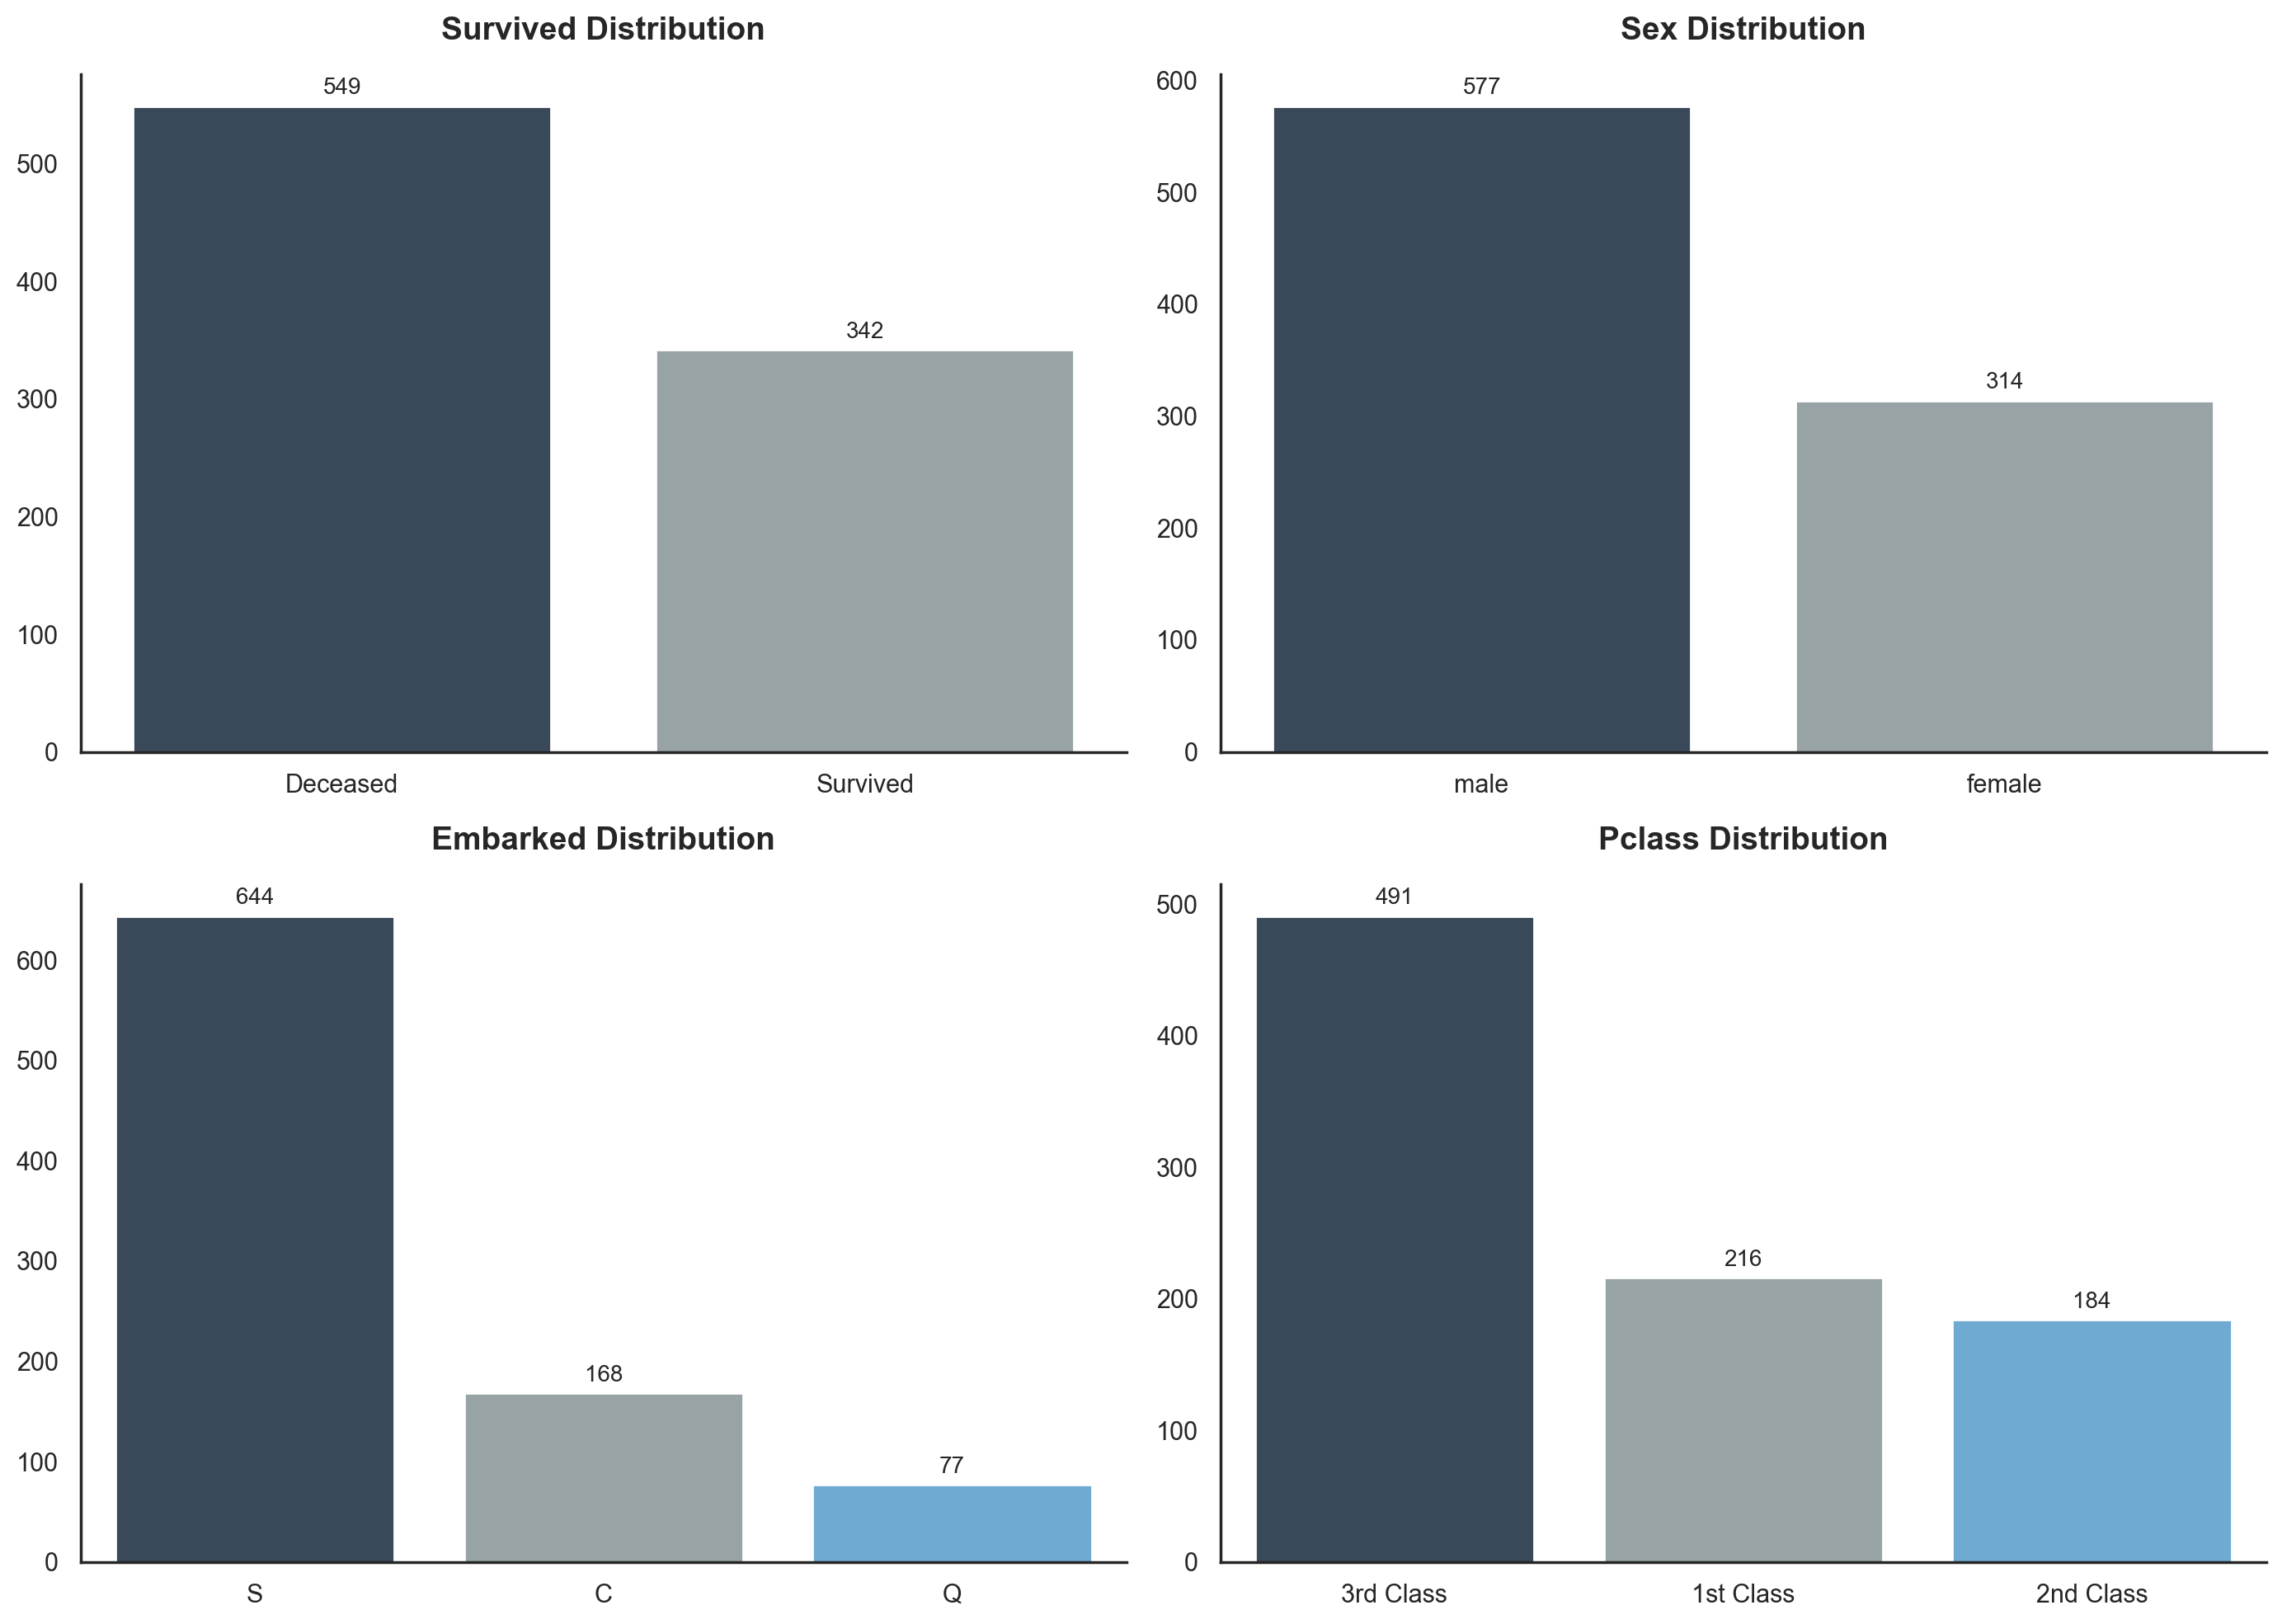

In [7]:
plot_df = train_df.copy()

plot_df['Survived'] = plot_df['Survived'].map({0: 'Deceased', 1: 'Survived'})
plot_df['Pclass'] = plot_df['Pclass'].map({1: '1st Class', 2: '2nd Class', 3: '3rd Class'})

cols_to_plot = ['Survived', 'Sex', 'Embarked', 'Pclass']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cols_to_plot):
    row, col_idx = i // 2, i % 2
    ax = axes[row, col_idx]

    sns.countplot(
        data=plot_df,
        x=col,
        palette=CUSTOM_PALETTE[:plot_df[col].nunique()],
        ax=ax
    )

    ax.set_title(f'{col} Distribution', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('')

    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=10)

plt.tight_layout()
plt.show()

**Target Variable (`Survived`)**  
The target variable shows a moderate class imbalance: 549 passengers did not survive (~61.6%) and 342 survived (~38.4%). Accuracy remains useful as a general metric, but it should not be interpreted in isolation because a majority-class baseline would already reach approximately 61.6% accuracy. For this reason, precision, recall, F1-score, and the confusion matrix are also required for model evaluation.

**Feature (`Sex`)**  
The training dataset contains more male passengers than female passengers, with 577 males and 314 females. This imbalance should be considered when interpreting survival patterns by sex in later bivariate analysis.

**Feature (`Pclass`)**  
Third-class passengers form the largest group, with 491 records, followed by first class with 216 records and second class with 184 records. Since `Pclass` is also a proxy for socioeconomic status, it is expected to be a relevant predictor in the survival model, although its actual contribution must be evaluated empirically.

**Feature (`Embarked`)**  
Southampton (`S`) is the dominant port of embarkation, with 644 passengers, followed by Cherbourg (`C`) with 168 and Queenstown (`Q`) with 77. In the raw training data, `Embarked` has only two missing values. These missing values are handled later using mode imputation fitted on the appropriate training partition.


#### Numerical Continuous Features

This step examines the raw distributions of `Age` and `Fare` using histograms with density curves and boxplots. The objective is to identify skewness, concentration patterns, missing-value implications, and potential outliers before applying imputation or feature engineering.

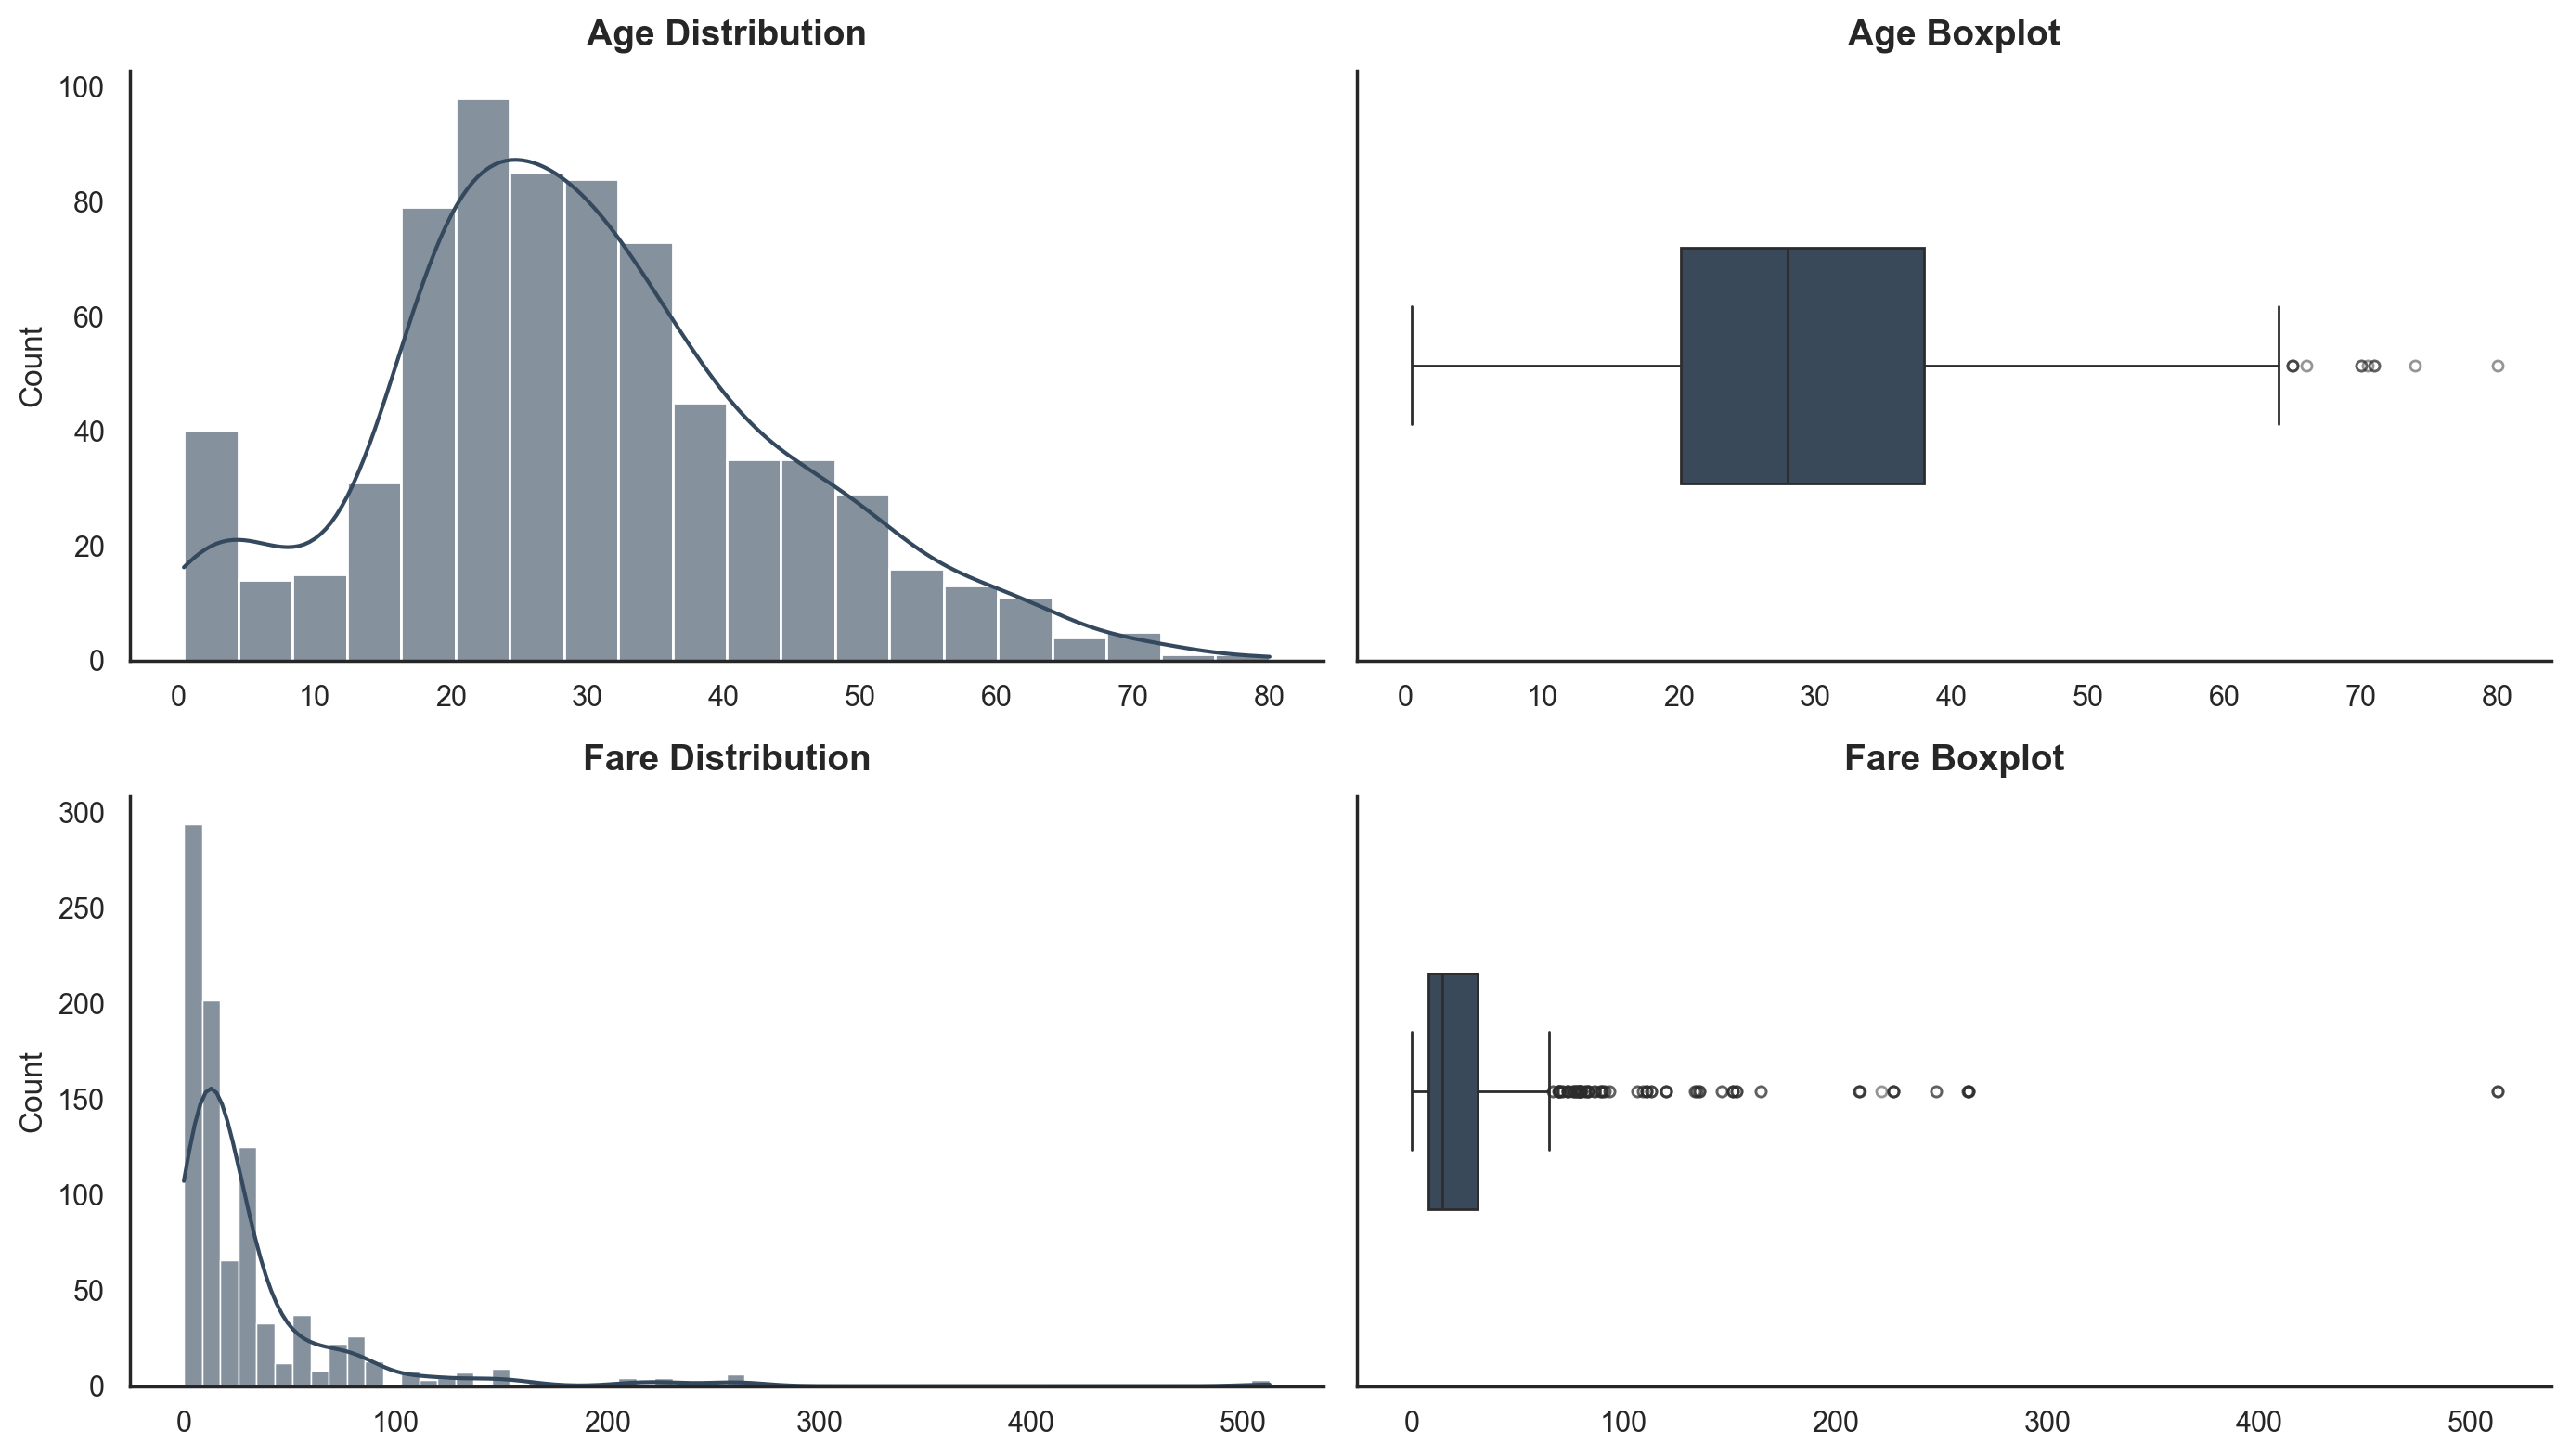

In [8]:
continuous_features = ["Age", "Fare"]

fig, axes = plt.subplots(len(continuous_features), 2, figsize=(14, 4 * len(continuous_features)))
primary_color = CUSTOM_PALETTE[0]

for i, feature in enumerate(continuous_features):
    ax_hist = axes[i, 0]
    ax_box = axes[i, 1]

    sns.histplot(
        data=train_df,
        x=feature,
        kde=True,
        ax=ax_hist,
        color=primary_color,
        alpha=0.6
    )
    ax_hist.set_title(f"{feature} Distribution", pad=10)
    ax_hist.set_xlabel("")
    ax_hist.set_ylabel("Count")

    sns.boxplot(
        data=train_df,
        x=feature,
        ax=ax_box,
        color=primary_color,
        width=0.4,
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5}
    )
    ax_box.set_title(f"{feature} Boxplot", pad=10)
    ax_box.set_xlabel("")

plt.tight_layout()
plt.show()

**Feature (`Age`)**  
The observed `Age` distribution, calculated only from non-missing values, is approximately unimodal and slightly right-skewed. Most passengers are concentrated between 20 and 40 years old, while a smaller number of observations appear among children and older passengers. Since `Age` contains missing values in the training dataset, the modeling pipeline must impute it before training.

**Feature (`Fare`)**  
The `Fare` distribution is highly right-skewed, with most passengers concentrated at relatively low fare values and a small number of extreme high-fare observations. This pattern suggests that the raw fare scale may be difficult to interpret directly and motivates later feature engineering, such as fare binning, while retaining the original numerical signal if supported by the modeling strategy.

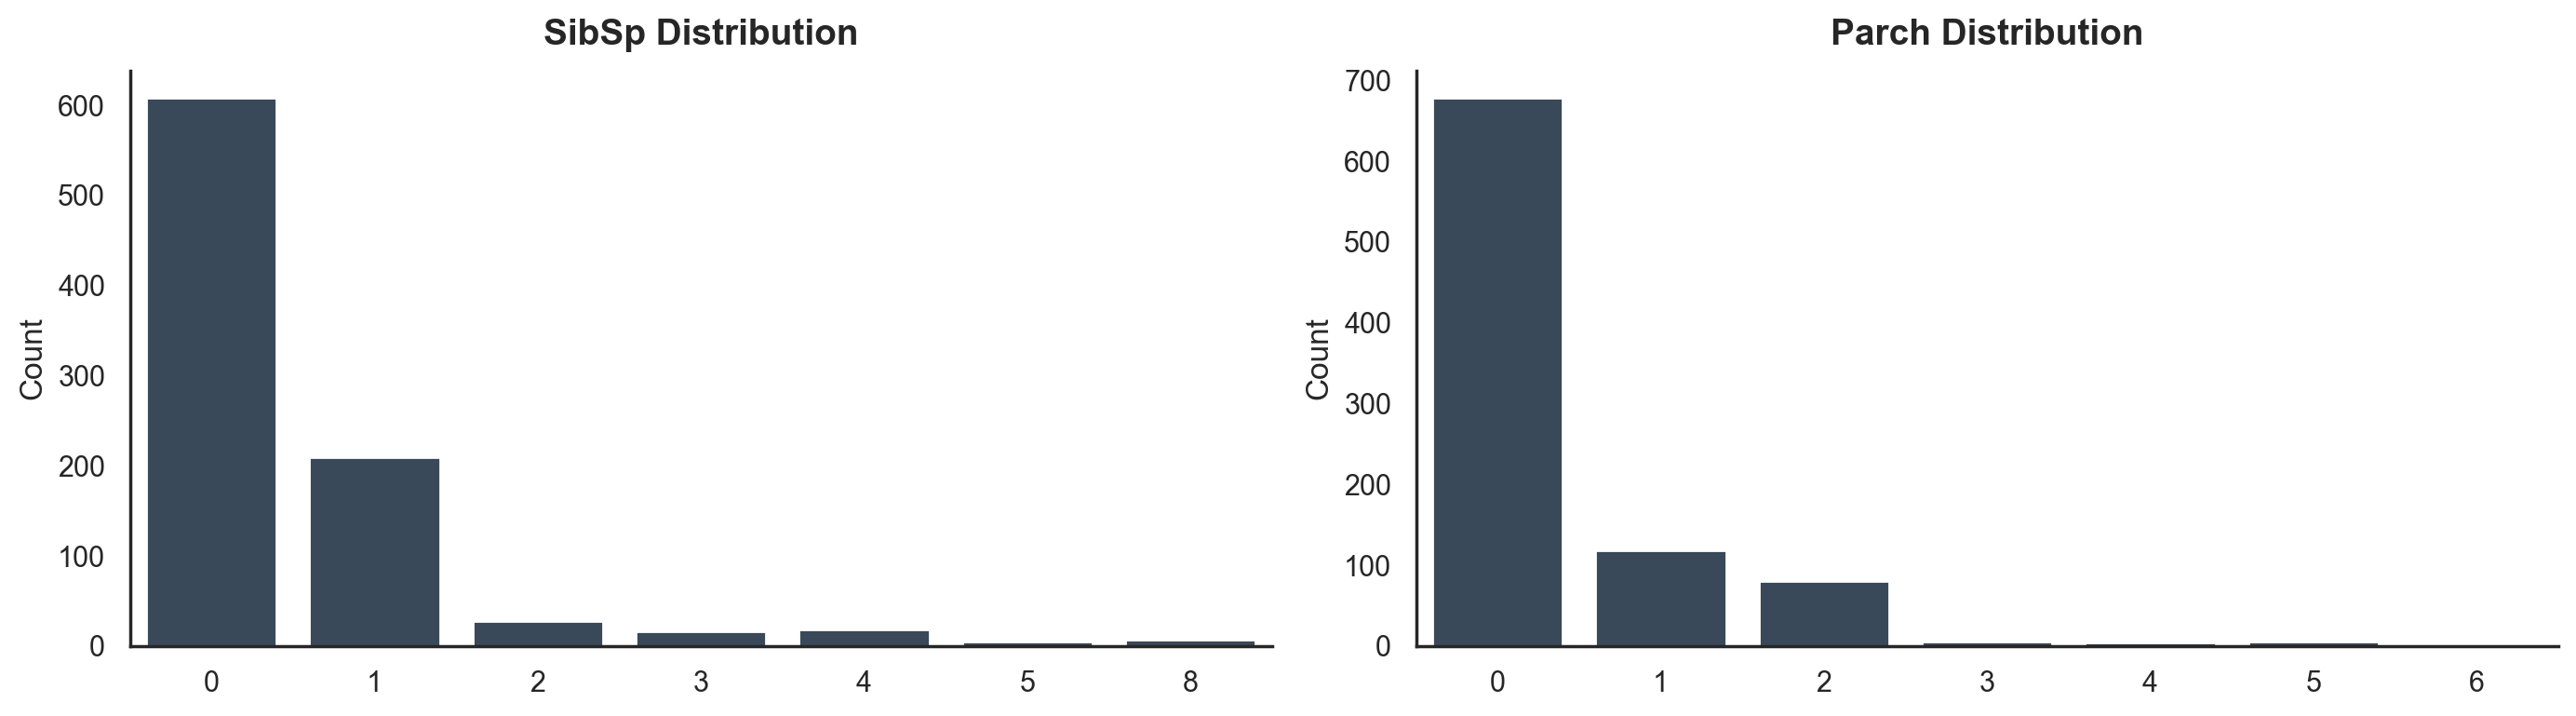

In [9]:
discrete_features = ["SibSp", "Parch"]

fig, axes = plt.subplots(1, len(discrete_features), figsize=(14, 4))
primary_color = CUSTOM_PALETTE[0]

for ax, feature in zip(axes, discrete_features):
    sns.countplot(data=train_df, x=feature, ax=ax, color=primary_color)
    ax.set_title(f"{feature} Distribution", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

**Features (`SibSp` and `Parch`)**  
Both variables are strongly concentrated at zero, indicating that most passengers had no recorded siblings/spouses (`SibSp`) or parents/children (`Parch`) aboard. Although they capture different family relationships, both describe aspects of the passenger's family structure on the ship. This motivates the later construction of an aggregated family-size feature, such as `FamilySize = SibSp + Parch + 1`, instead of relying only on the two raw variables independently.

### Bivariate Analysis

We analyze the relationship between selected categorical and discrete features and the target variable to identify descriptive associations that may inform preprocessing and feature engineering. At this stage, the analysis is exploratory and should not be interpreted as causal evidence.

#### Categorical and Discrete Features vs. Target

The following plots show survival counts across selected categorical and discrete variables. Since these are absolute counts, they should be interpreted alongside category-level survival rates, especially when the category sizes are imbalanced.

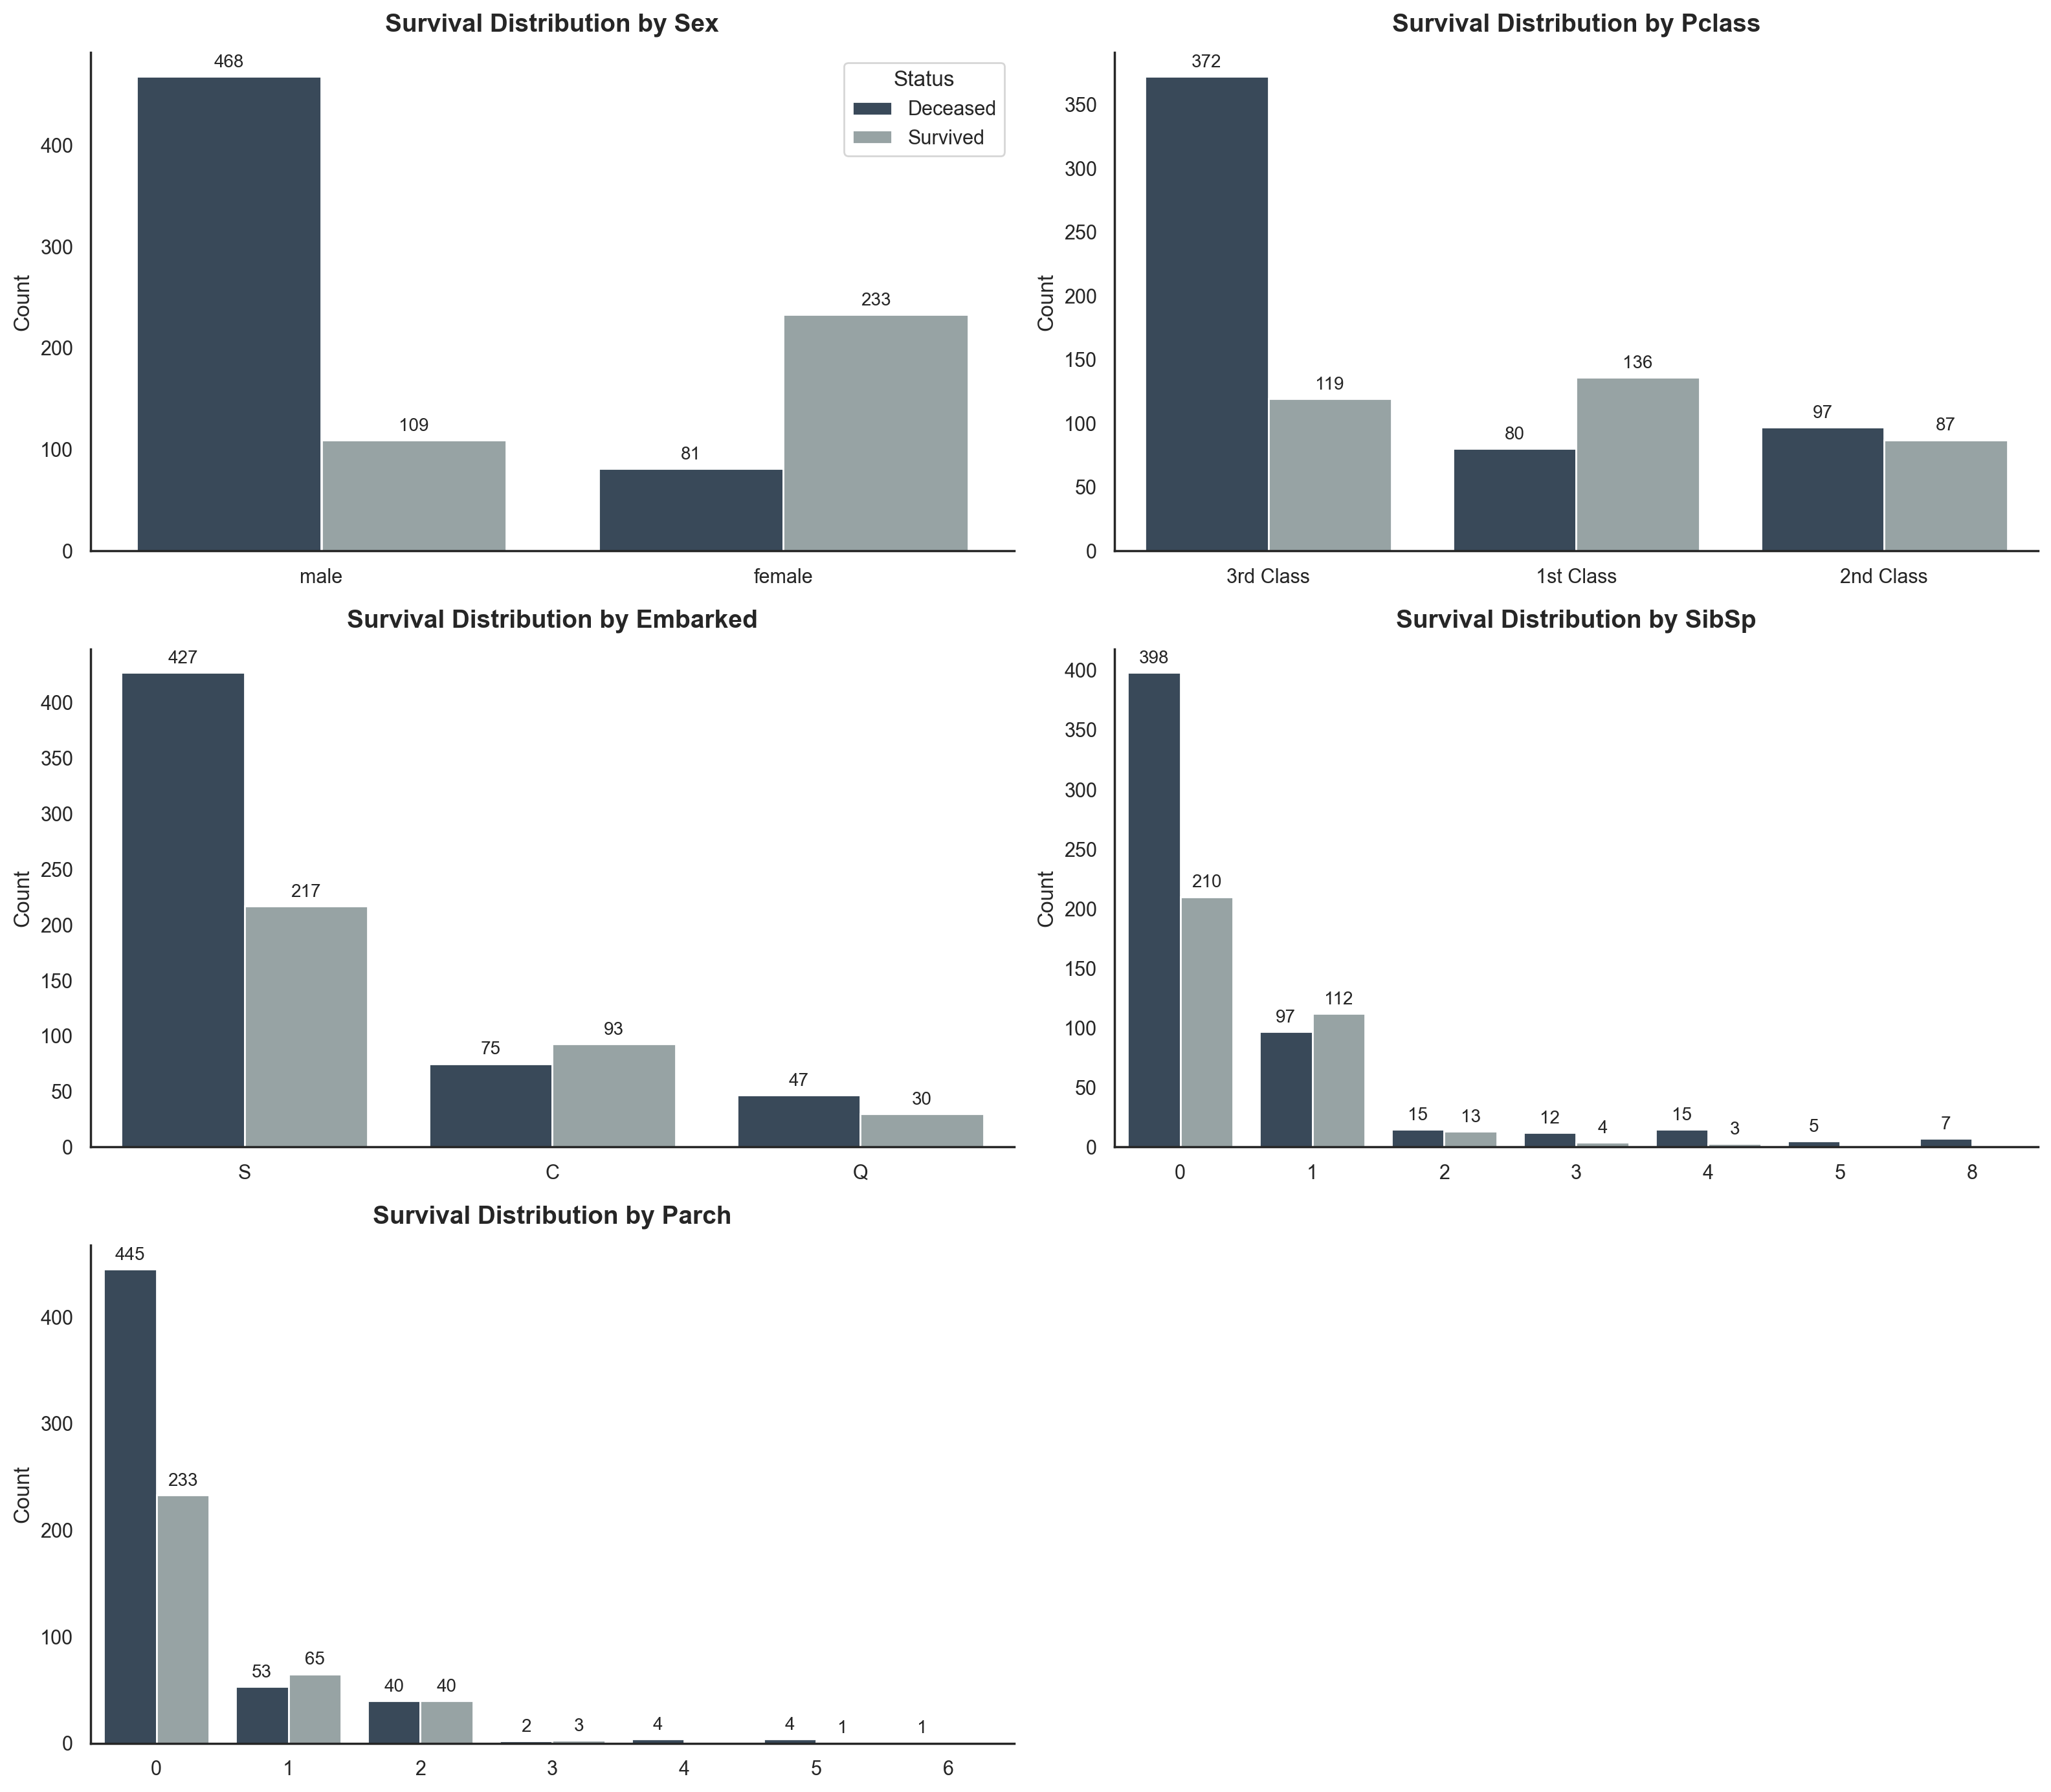

In [10]:
cols_bivariate = ['Sex', 'Pclass', 'Embarked', 'SibSp', 'Parch']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes_flat = axes.flatten()

for i, feature in enumerate(cols_bivariate):
    ax = axes_flat[i]

    sns.countplot(
        data=plot_df,
        x=feature,
        hue='Survived',
        hue_order=['Deceased', 'Survived'],
        palette=CUSTOM_PALETTE[:2],
        ax=ax
    )

    ax.set_title(f'Survival Distribution by {feature}', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

    if i == 0:
        ax.legend(title='Status', loc='upper right')
    else:
        ax.get_legend().remove()

    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=10)

fig.delaxes(axes_flat[-1])

plt.tight_layout()
plt.show()

**Feature (`Sex`)**  
Survival outcomes differ substantially by sex in the training data. Female passengers show a higher observed survival proportion than male passengers, making `Sex` a strong candidate predictor for this dataset.

**Feature (`Pclass`)**  
Survival is strongly associated with ticket class in the training data. First-class passengers show a higher observed survival proportion, while third-class passengers show a lower observed survival proportion. This supports the interpretation of `Pclass` as a socioeconomic proxy, although its predictive contribution should still be evaluated empirically during modeling.

**Feature (`Embarked`)**  
Passengers embarking from Cherbourg (`C`) show a higher observed survival proportion than those embarking from Southampton (`S`) or Queenstown (`Q`). This pattern should not be interpreted as a direct causal effect of the port itself, since it may reflect differences in passenger composition, such as class, fare, or demographic profile.

**Features (`SibSp` and `Parch`)**  
Survival patterns vary across the discrete family-related variables `SibSp` and `Parch`, but the higher-count categories are concentrated at small values. Categories with larger values are sparse and should be interpreted cautiously. A more direct analysis of family structure requires an aggregated feature such as `FamilySize = SibSp + Parch + 1`.


#### Continuous Features vs. Target

This step compares the distribution of continuous numerical features across survival status using kernel density estimates. These plots are descriptive and should be interpreted as differences in feature distributions between outcome groups, not as direct estimates of survival probability. Survival-rate claims require complementary grouped statistics.

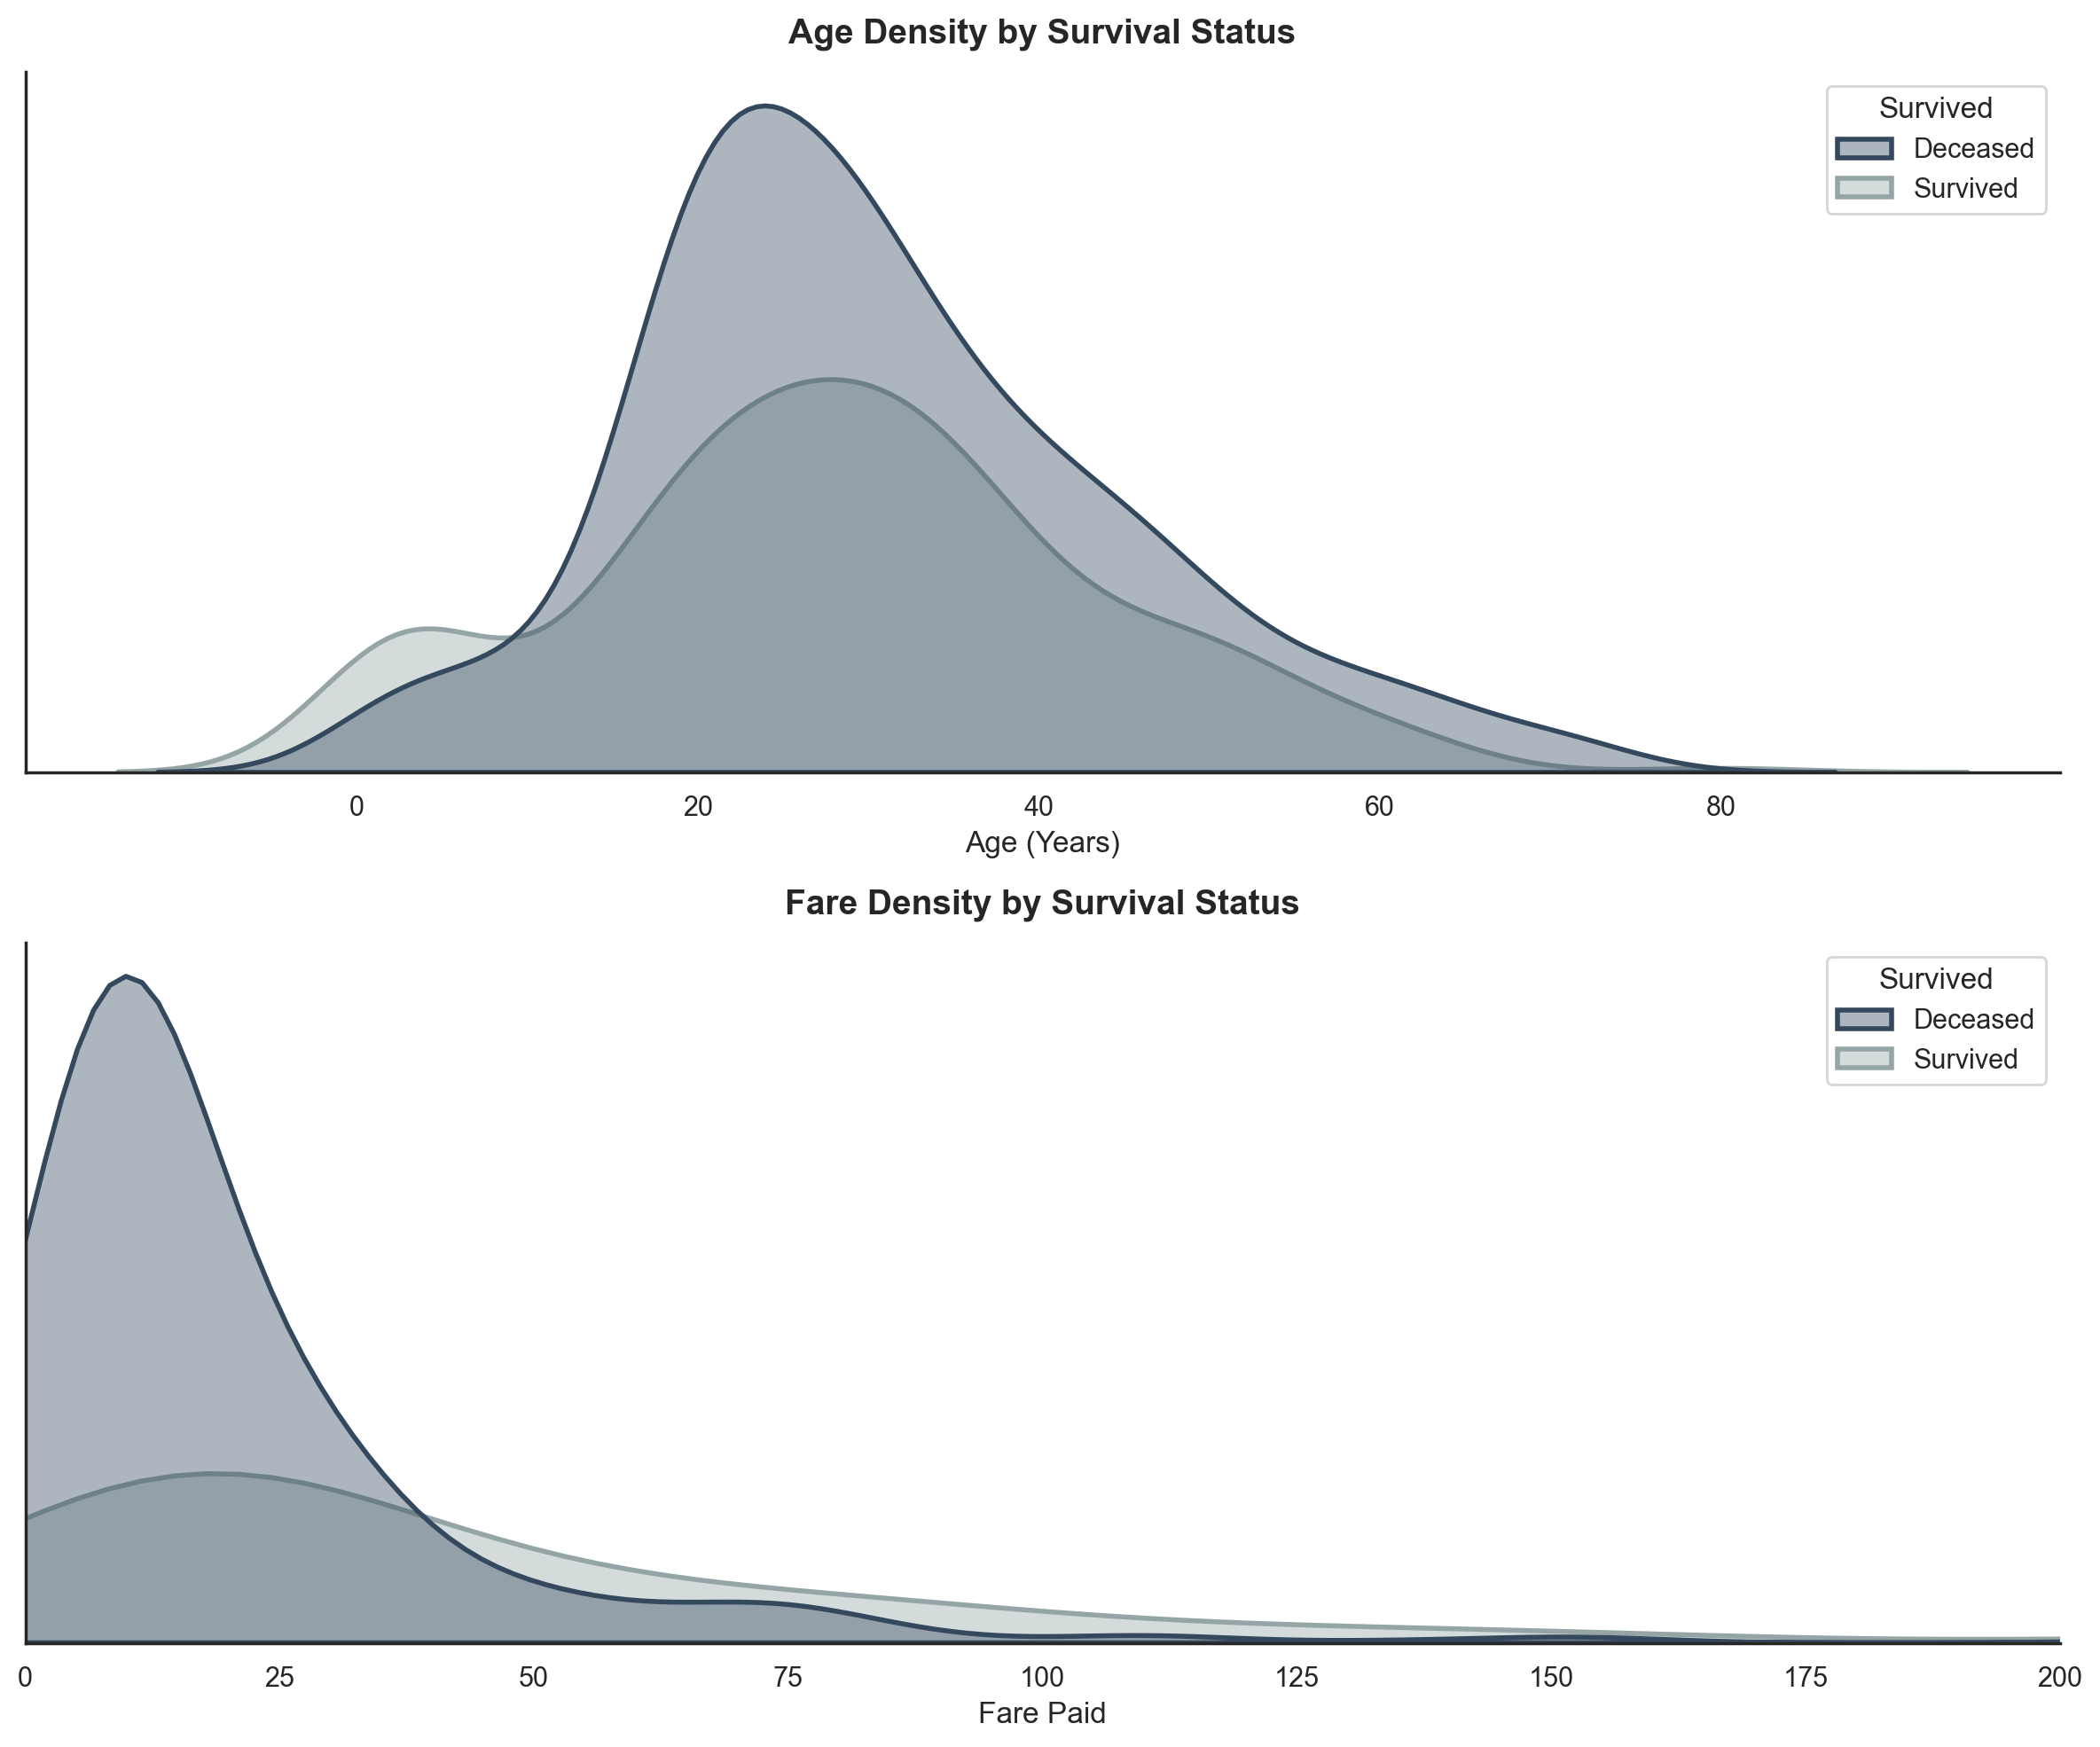

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Age density; rows with missing Age are excluded for this plot only.
sns.kdeplot(
    data=plot_df.dropna(subset=["Age"]),
    x="Age",
    hue="Survived",
    fill=True,
    alpha=0.4,
    linewidth=2,
    palette=CUSTOM_PALETTE[:2],
    ax=axes[0]
)
axes[0].set_title("Age Density by Survival Status", pad=12)
axes[0].set_xlabel("Age (Years)")
axes[0].set_ylabel("")
axes[0].set_yticks([])

# Fare density.
sns.kdeplot(
    data=plot_df,
    x="Fare",
    hue="Survived",
    fill=True,
    alpha=0.4,
    linewidth=2,
    palette=CUSTOM_PALETTE[:2],
    ax=axes[1]
)
axes[1].set_title("Fare Density by Survival Status", pad=12)
axes[1].set_xlabel("Fare Paid")
axes[1].set_ylabel("")
axes[1].set_yticks([])

# Limit x-axis range for readability; extreme fare outliers remain in the data.
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()

**Feature (`Age`)**  
The age distributions of survivors and non-survivors overlap substantially across most adult age ranges. However, the density profile suggests a relative difference among younger passengers, where survivors appear more represented. This indicates that the relationship between age and survival may be non-linear, motivating the later use of grouped age representations such as `AgeBin`.

**Feature (`Fare`)**  
The fare distributions differ markedly by survival status. Non-survivors are more concentrated at lower fare values, while survivors are relatively more represented across higher fare ranges. Because `Fare` is strongly right-skewed and contains extreme values, the pipeline retains the raw `Fare` variable while also creating `FareBin` to represent broader fare intervals and potential non-linear effects.


### Correlation Analysis

We examine Pearson linear correlations as a descriptive diagnostic for numerical associations among selected variables and the target. These correlations are not used directly by CatBoost and do not establish causality. Categorical variables encoded numerically in this section, such as `Sex_Code` and `Embarked_Code`, are included only for exploratory diagnostics; their coefficients should be interpreted cautiously, especially for nominal variables.

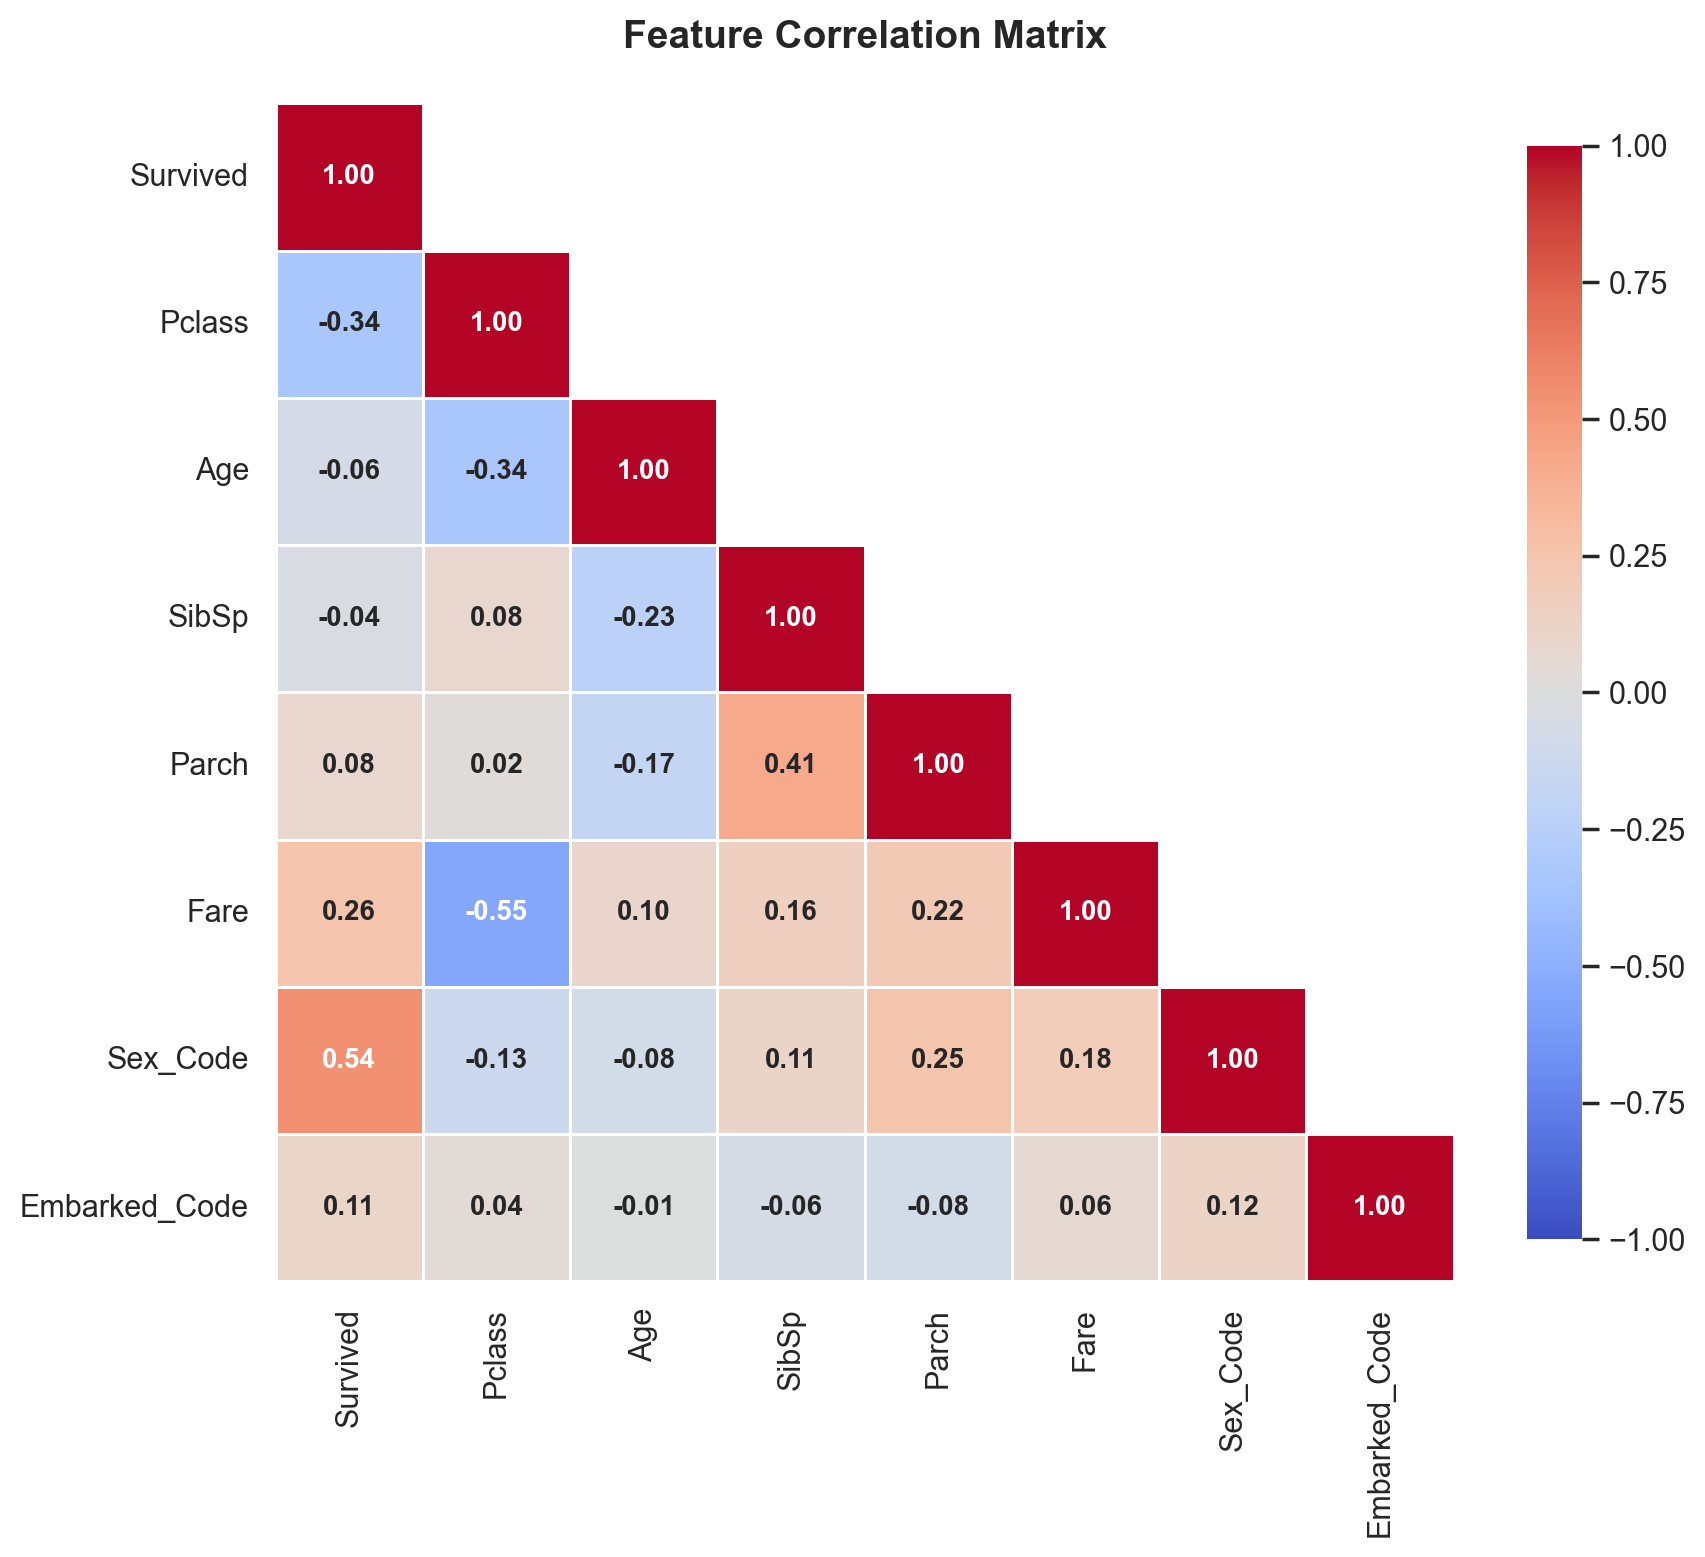

In [12]:
plot_df = train_df.copy()

plot_df["Sex_Code"] = plot_df["Sex"].map({"male": 0, "female": 1})
plot_df["Embarked_Code"] = plot_df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Temporary Age imputation for this correlation diagnostic only.
plot_df["Age"] = plot_df["Age"].fillna(plot_df["Age"].median())

cols_to_corr = [
    "Survived", "Pclass", "Age", "SibSp",
    "Parch", "Fare", "Sex_Code", "Embarked_Code"
]

corr_matrix = plot_df[cols_to_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(9, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    square=True,
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"shrink": .8}
)

plt.title("Feature Correlation Matrix", pad=20, weight='bold')
plt.tight_layout()
plt.show()

**Target Correlations**  
In this linear correlation view, `Sex_Code` shows the strongest association with survival. `Pclass` has the second-largest association in absolute terms and is negatively correlated with survival because higher numeric class values represent lower ticket classes. `Fare` shows a positive correlation with survival, consistent with the relationship between fare, class, and socioeconomic status.

**Predictor Correlations**  
The negative correlation between `Pclass` and `Fare` reflects their economic relationship: passengers in higher classes generally paid higher fares, while third-class passengers generally paid lower fares. The moderate positive correlation between `SibSp` and `Parch` suggests that both variables capture related aspects of family structure aboard the ship, supporting the later construction of an aggregated `FamilySize` feature.

### Key Insights from EDA

* **`Sex` and `Pclass` show the clearest observed associations with survival.**  
  The exploratory analysis indicates substantial differences in survival patterns across sex and ticket class groups. These variables are therefore expected to provide strong predictive signal, although their contribution must still be validated during model training.

* **`Age` and `Fare` suggest potentially non-linear patterns.**  
  The density plots and distributional differences indicate that their relationship with survival may not be fully captured by a simple linear effect. This motivates grouped representations such as `AgeBin` and `FareBin` in the downstream pipeline.

* **Family-related variables capture complementary aspects of passenger structure.**  
  `SibSp` and `Parch` both describe family relationships aboard the ship. Combining them into `FamilySize` provides a more compact representation of the passenger's family context and reduces reliance on the two raw components separately.

* **Predictor correlations do not prevent the use of a tree-based model, but they affect interpretation.**  
  CatBoost can handle correlated predictors during training, but correlation among variables should be considered when interpreting feature importance, SHAP values, or marginal effects.

* **`Embarked` provides a secondary categorical signal.**  
  Differences across embarkation ports appear to be associated with survival patterns, but this signal is likely indirect and may reflect passenger composition, fare, class, or demographic differences rather than a causal port effect.

These findings guide the feature engineering phase by motivating transformations and derived variables that reflect structure observed in the training data, while keeping the final assessment dependent on validation results.


## 4. Preprocessing Strategy

This section defines the cleaning strategy applied before feature engineering. To avoid data leakage, imputation statistics are learned only from the appropriate fitting partition: the full training feature set when fitting the final Kaggle submission model, the internal training split during holdout validation, and each fold's training rows during cross-validation.


### Missing Values Analysis (Test Dataset)

After inspecting the training data, we also inspect the test dataset to identify missing values that may affect inference. This step is necessary because unseen data can contain nulls even in features that appear complete in the training set.

In [13]:
test_nulls = test_df.isnull()

test_null_summary = pd.DataFrame({
    "Missing Values": test_nulls.sum(),
    "Percentage (%)": (test_nulls.mean() * 100).round(2),
}).sort_values(by="Missing Values", ascending=False)

display(test_null_summary[test_null_summary["Missing Values"] > 0])

,Missing Values,Percentage (%)
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24


The test dataset contains missing values in `Cabin`, `Age`, and `Fare`. `Cabin` and `Age` show a missing-value pattern similar to the training dataset, with high sparsity in `Cabin` and approximately 20% missing values in `Age`.

A notable test-specific edge case appears in `Fare`, which contains one missing value despite being complete in the training dataset. Although this represents only 0.24% of the test records, it still requires explicit handling to ensure that inference can be performed without errors.

For this reason, the preprocessing pipeline must define robust imputation rules for all relevant variables, including features that may be complete in the training data but incomplete in the test or future inference data.

### Cleaning Pipeline

The cleaning pipeline is organized into three stages:  
1. define reusable preprocessing functions,  
2. learn imputation statistics from a fitting dataset only, and  
3. apply the same transformations consistently to downstream datasets.


In [14]:
def fit_embarked(df: pd.DataFrame) -> str:
    """Learn the mode of the Embarked feature from the fitting data."""
    return df["Embarked"].mode(dropna=True)[0]


def transform_embarked(df: pd.DataFrame, embarked_mode: str) -> pd.DataFrame:
    """Fill missing Embarked values using the learned mode."""
    df_out = df.copy()
    df_out["Embarked"] = df_out["Embarked"].fillna(embarked_mode)
    return df_out


def fit_fare(df: pd.DataFrame) -> tuple[pd.Series, float]:
    """Learn Fare medians by Pclass and a global fallback median."""
    fare_by_class = df.groupby("Pclass")["Fare"].median()
    fare_global = df["Fare"].median()
    return fare_by_class, fare_global


def transform_fare(
    df: pd.DataFrame,
    fare_by_class: pd.Series,
    fare_global: float
) -> pd.DataFrame:
    """Fill missing Fare values using class-level medians with global fallback."""
    df_out = df.copy()

    mapped_fares = df_out["Pclass"].map(fare_by_class)
    df_out["Fare"] = df_out["Fare"].fillna(mapped_fares)
    df_out["Fare"] = df_out["Fare"].fillna(fare_global)

    return df_out


def fit_age(df: pd.DataFrame) -> tuple[pd.Series, float]:
    """Learn Age medians by Sex and Pclass, plus a global fallback median."""
    age_by_group = df.groupby(["Sex", "Pclass"])["Age"].median()
    age_global = df["Age"].median()
    return age_by_group, age_global


def transform_age(
    df: pd.DataFrame,
    age_by_group: pd.Series,
    age_global: float
) -> pd.DataFrame:
    """Fill missing Age values using group-level medians with global fallback."""
    df_out = df.copy()

    group_index = pd.MultiIndex.from_arrays([df_out["Sex"], df_out["Pclass"]])
    mapped_ages = pd.Series(group_index.map(age_by_group), index=df_out.index)

    df_out["Age"] = df_out["Age"].fillna(mapped_ages)
    df_out["Age"] = df_out["Age"].fillna(age_global)

    return df_out


def fit_cleaning_statistics(df: pd.DataFrame) -> dict[str, object]:
    """Learn all imputation statistics from the provided fitting data only."""
    fare_by_class, fare_global = fit_fare(df)
    age_by_group, age_global = fit_age(df)

    return {
        "embarked_mode": fit_embarked(df),
        "fare_by_class": fare_by_class,
        "fare_global": fare_global,
        "age_by_group": age_by_group,
        "age_global": age_global,
    }


def transform_cabin(df: pd.DataFrame) -> pd.DataFrame:
    """Replace missing Cabin values with an explicit unknown category."""
    df_out = df.copy()
    df_out["Cabin"] = df_out["Cabin"].fillna("U")
    return df_out


def drop_non_predictive_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Drop identifier columns that do not carry predictive signal."""
    df_out = df.copy()
    df_out = df_out.drop(columns=["PassengerId"], errors="ignore")
    return df_out


def execute_cleaning_pipeline(
    df: pd.DataFrame,
    embarked_mode: str,
    fare_by_class: pd.Series,
    fare_global: float,
    age_by_group: pd.Series,
    age_global: float
) -> pd.DataFrame:
    """Apply the full cleaning pipeline consistently."""
    df_out = transform_embarked(df, embarked_mode)
    df_out = transform_fare(df_out, fare_by_class, fare_global)
    df_out = transform_age(df_out, age_by_group, age_global)
    df_out = transform_cabin(df_out)
    df_out = drop_non_predictive_columns(df_out)
    return df_out


For categorical data, the `Embarked` feature is imputed using its statistical mode because missing values are rare and the distribution is concentrated.

The `Fare` feature is imputed using class-level medians (`Pclass`), with a global median fallback for unseen or missing class-specific values.

`Age` is imputed using group-level medians (`Sex` and `Pclass`), with a global median fallback.

The `Cabin` feature, which is highly sparse, is transformed by replacing missing values with an explicit `"U"` (Unknown) category so that missingness can be represented as a categorical state.


In [15]:
full_training_features = train_df.drop(columns=["Survived"])
full_cleaning_stats = fit_cleaning_statistics(full_training_features)

learned_embarked_mode = full_cleaning_stats["embarked_mode"]
learned_fare_by_class = full_cleaning_stats["fare_by_class"]
learned_fare_global = full_cleaning_stats["fare_global"]
learned_age_by_group = full_cleaning_stats["age_by_group"]
learned_age_global = full_cleaning_stats["age_global"]


In [16]:
train_clean = execute_cleaning_pipeline(
    train_df,
    learned_embarked_mode,
    learned_fare_by_class,
    learned_fare_global,
    learned_age_by_group,
    learned_age_global
)

test_clean = execute_cleaning_pipeline(
    test_df,
    learned_embarked_mode,
    learned_fare_by_class,
    learned_fare_global,
    learned_age_by_group,
    learned_age_global
)

The resulting datasets (`train_clean` and `test_clean`) are free of missing values, providing a consistent foundation for the subsequent feature engineering stage.


## 5. Feature Engineering

This section creates derived attributes from passenger names, family composition, age, fare, and the interaction between sex and ticket class. These transformations are motivated by exploratory patterns observed during EDA and by domain knowledge about the Titanic dataset.

In [17]:
def transform_extract_titles(df: pd.DataFrame) -> pd.DataFrame:
    df_out = df.copy()
    df_out["Title"] = df_out["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)

    title_map = {
        "Mr": "Mr",
        "Miss": "Miss",
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mrs": "Mrs",
        "Mme": "Mrs",
        "Master": "Master"
    }

    df_out["Title"] = df_out["Title"].map(title_map).fillna("Rare")
    return df_out

def transform_is_married(df: pd.DataFrame) -> pd.DataFrame:
    df_out = df.copy()
    df_out["IsMarried"] = (df_out["Title"] == "Mrs").astype(int)
    return df_out

def transform_family_features(df: pd.DataFrame) -> pd.DataFrame:
    df_out = df.copy()
    df_out["FamilySize"] = df_out["SibSp"] + df_out["Parch"] + 1
    return df_out

def transform_age_bin(df: pd.DataFrame) -> pd.DataFrame:
    df_out = df.copy()
    bins = [-np.inf, 15.5, 21.5, 63.5, np.inf]
    labels = [
        "AgeBin_le_15_5",
        "AgeBin_15_5_21_5",
        "AgeBin_21_5_63_5",
        "AgeBin_gt_63_5"
    ]
    age_bin = pd.cut(df_out["Age"], bins=bins, labels=labels, include_lowest=True)
    df_out["AgeBin"] = pd.Series(age_bin, index=df_out.index, dtype="string").fillna("AgeBin_Unknown")
    return df_out

def transform_fare_bin(df: pd.DataFrame) -> pd.DataFrame:
    df_out = df.copy()
    bins = [-np.inf, 10.5, 51.0, 74.4, np.inf]
    labels = [
        "FareBin_le_10_5",
        "FareBin_10_5_51_0",
        "FareBin_51_0_74_4",
        "FareBin_gt_74_4"
    ]
    fare_bin = pd.cut(df_out["Fare"], bins=bins, labels=labels, include_lowest=True)
    df_out["FareBin"] = pd.Series(fare_bin, index=df_out.index, dtype="string").fillna("FareBin_Unknown")
    return df_out

def transform_sex_pclass_interaction(df: pd.DataFrame) -> pd.DataFrame:
    df_out = df.copy()
    df_out["Sex_Pclass"] = df_out["Sex"].astype(str) + "_" + df_out["Pclass"].astype(str)
    return df_out

def execute_engineering_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    df_eng = df.copy()
    df_eng = transform_extract_titles(df_eng)
    df_eng = transform_is_married(df_eng)
    df_eng = transform_family_features(df_eng)
    df_eng = transform_age_bin(df_eng)
    df_eng = transform_fare_bin(df_eng)
    df_eng = transform_sex_pclass_interaction(df_eng)
    return df_eng


### Features Used in the Final Pipeline

The following engineered features are created and used in the executed modeling pipeline:

- **`Title`**  
  Extracted from the `Name` field. This feature represents honorific titles that may encode social role, age group, gender conventions, or marital status. In the current experiment version, the raw `Name` column is also retained as a categorical/text predictor.

- **`IsMarried`**  
  Binary indicator derived from `Title`, equal to 1 for `Mrs` and 0 otherwise.

- **`FamilySize`**  
  Combines `SibSp` and `Parch` into a single count representing the passenger's recorded family group size aboard.

- **`AgeBin`**  
  Discretized age feature using fixed cut points. The imputed raw `Age` value is also retained, while the bin provides a grouped representation that may help capture non-linear age patterns.

- **`FareBin`**  
  Discretized fare feature using fixed fare bands. The imputed raw `Fare` value is also retained, while the bin provides a grouped representation of broad fare ranges.

- **`Sex_Pclass`**  
  Interaction feature combining sex and ticket class, explicitly exposing a high-level demographic and socioeconomic grouping to the model.

- **`Ticket`**  
  Retained as a high-cardinality categorical predictor and passed to CatBoost through `cat_features`.

In addition to the engineered features, the cleaned `Cabin` field is retained as a categorical predictor after replacing missing values with `U`.

After dropping the original family-count columns (`SibSp` and `Parch`), the final predictor matrix used by CatBoost contains 14 predictors: `Pclass`, `Name`, `Sex`, `Age`, `Ticket`, `Fare`, `Cabin`, `Embarked`, `Title`, `IsMarried`, `FamilySize`, `AgeBin`, `FareBin`, and `Sex_Pclass`.

In [18]:
# Current model selection: drop only the original family-count columns after
# creating FamilySize. Name, Ticket, Fare, and Age were tested for removal in
# later experiments, but they are retained in the current best model.
columns_to_drop = [
    "SibSp",
    "Parch",
]


def build_model_matrix(raw_df: pd.DataFrame, cleaning_stats: dict[str, object]) -> pd.DataFrame:
    """Clean, engineer, and select final predictors using pre-fitted cleaning stats."""
    clean_df = execute_cleaning_pipeline(
        raw_df,
        cleaning_stats["embarked_mode"],
        cleaning_stats["fare_by_class"],
        cleaning_stats["fare_global"],
        cleaning_stats["age_by_group"],
        cleaning_stats["age_global"],
    )
    eng_df = execute_engineering_pipeline(clean_df)
    return eng_df.drop(columns=columns_to_drop, errors="ignore")


def prepare_fold_matrices(
    X_train_raw: pd.DataFrame,
    X_valid_raw: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame, list[str], dict[str, object]]:
    """Fit preprocessing on one training partition and apply it to its validation partition."""
    fold_cleaning_stats = fit_cleaning_statistics(X_train_raw)

    X_train = build_model_matrix(X_train_raw, fold_cleaning_stats)
    X_valid = build_model_matrix(X_valid_raw, fold_cleaning_stats)
    X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)

    cat_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

    return X_train, X_valid, cat_features, fold_cleaning_stats


train_eng = execute_engineering_pipeline(train_clean)
test_eng = execute_engineering_pipeline(test_clean)

train_final = train_eng.drop(columns=columns_to_drop, errors="ignore")
test_final = test_eng.drop(columns=columns_to_drop, errors="ignore")


The final engineered feature set preserves information related to socioeconomic status, sex, family structure, grouped age and fare ranges, ticket identity, passenger title, and the cleaned cabin signal.

### Final Modeling Inputs

For the final Kaggle submission path, the target variable is separated from the fully processed training dataset, producing the final labeled feature matrix and target vector used for full-data model fitting. The Kaggle test set is kept as the inference matrix.

The assertion verifies that the training and test feature matrices share the same columns in the same order before final model fitting and test prediction.

Local validation is handled separately in the next section using a raw-data split, allowing preprocessing statistics to be learned only from the relevant training partition.


In [19]:
y_train = train_final["Survived"].astype(int)
X_train = train_final.drop(columns=["Survived"])
X_test = test_final.copy()

assert "Survived" not in X_train.columns
assert "Survived" not in X_test.columns
assert list(X_train.columns) == list(X_test.columns)
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

## 6. Modeling, Optimization, and Validation

This section defines the modeling inputs, identifies categorical predictors for CatBoost, creates a leakage-controlled holdout and cross-validation strategy, runs Optuna hyperparameter optimization, evaluates local validation results, and trains the final estimator used for Kaggle submission.


### Model Evaluated: CatBoost with Native Categorical Handling

The experiment evaluates CatBoost as the predictive model for this tabular classification task. CatBoost is appropriate for this setup because the final feature matrix combines numerical predictors, grouped features, high-cardinality categorical variables, and engineered categorical interactions. Instead of expanding categories through one-hot encoding, the pipeline passes categorical predictors directly to CatBoost through the `cat_features` argument.

In the final training path used for Kaggle submission, `cat_features` includes all `object`, `string`, and `category` columns, plus selected integer-coded predictors that are treated as categorical: `Pclass`, `IsMarried`, and `FamilySize`. This configuration is retained as the current baseline because it produced the best Kaggle result observed in this notebook's experiment log.

In [20]:
catboost_cat_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist() + ["Pclass", "IsMarried", "FamilySize"]

### Validation Strategy: Holdout Set and Internal Cross-Validation

The notebook uses a two-stage local validation strategy starting from the raw labeled training data.

First, 20% of the raw training rows are isolated as a holdout set. For this holdout validation, cleaning statistics are learned only from the remaining 80% and then applied to the holdout rows.

Second, Optuna evaluates each trial using 5-fold stratified cross-validation within that internal training split. For fold-safe cross-validation, each fold must learn its own imputation statistics from that fold's training rows only and apply them to the corresponding validation rows.

This prevents `Embarked` mode imputation, `Fare` median imputation, and `Age` median imputation from being influenced by the validation rows on which the model is later evaluated.


In [21]:
y_model = train_df["Survived"].astype(int)
X_model_raw = train_df.drop(columns=["Survived"])

X_fit_raw, X_holdout_raw, y_fit, y_holdout = train_test_split(
    X_model_raw,
    y_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_model
)

# Holdout validation: fit preprocessing only on the local training split, then apply it to holdout.
X_fit, X_holdout, validation_cat_features, holdout_cleaning_stats = prepare_fold_matrices(
    X_fit_raw,
    X_holdout_raw
)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


### Hyperparameter Optimization with Optuna

Optuna is used for sequential hyperparameter optimization. Instead of evaluating a fixed grid, Optuna adaptively proposes configurations based on the results of previous trials.

Each trial is evaluated through stratified cross-validation on the internal raw training split. For each fold, the cleaning and feature-engineering matrix is rebuilt after fitting imputation statistics only on the fold's training rows. After the search, the best configuration is refit on the full internal training split (`X_fit`, `y_fit`) before holdout evaluation.

The Optuna objective uses the categorical feature list returned by `prepare_fold_matrices`. As noted above, this list is narrower than the final submission `cat_features` list and should be synchronized in a future pipeline cleanup.


In [22]:
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 800, 1200),
        "depth": trial.suggest_int("depth", 5, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.05, log=True),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 2, 8),
        "random_strength": trial.suggest_float("random_strength", 0.5, 2.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "loss_function": "Logloss",
        "eval_metric": "Accuracy",
        "random_seed": RANDOM_STATE,
        "verbose": False,
        "thread_count": -1,
    }

    scores = []

    for train_idx, valid_idx in cv_strategy.split(X_fit_raw, y_fit):
        X_train_fold_raw = X_fit_raw.iloc[train_idx]
        X_valid_fold_raw = X_fit_raw.iloc[valid_idx]
        y_train_fold = y_fit.iloc[train_idx]
        y_valid_fold = y_fit.iloc[valid_idx]

        X_train_fold, X_valid_fold, fold_cat_features, _ = prepare_fold_matrices(
            X_train_fold_raw,
            X_valid_fold_raw
        )

        model = CatBoostClassifier(**params)

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=(X_valid_fold, y_valid_fold),
            early_stopping_rounds=50,
            use_best_model=True,
            cat_features=fold_cat_features,
        )

        y_pred = model.predict(X_valid_fold).ravel().astype(int)
        scores.append(accuracy_score(y_valid_fold, y_pred))

    return float(np.mean(scores))


optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
)

study.enqueue_trial({
    "iterations": 1000,
    "depth": 6,
    "learning_rate": 0.03,
    "l2_leaf_reg": 3,
    "random_strength": 1.0,
    "bagging_temperature": 1.0,
})

study.optimize(objective, n_trials=30)

print(f"Best CV Accuracy: {study.best_value:.4f}")
print(f"Best parameters: {study.best_params}")

best_optuna_model = CatBoostClassifier(
    **study.best_params,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=RANDOM_STATE,
    verbose=False,
)

best_optuna_model.fit(
    X_fit,
    y_fit,
    cat_features=validation_cat_features
)

Best CV Accuracy: 0.8553
Best parameters: {'iterations': 1037, 'depth': 5, 'learning_rate': 0.03665819462253379, 'l2_leaf_reg': 5, 'random_strength': 1.3792021089374082, 'bagging_temperature': 0.4971735467658833}


CatBoostClassifier(bagging_temperature=0.4971735467658833, depth=5, eval_metric='Accuracy', iterations=1037, l2_leaf_reg=5, learning_rate=0.03665819462253379, loss_function='Logloss', random_seed=42, random_strength=1.3792021089374082, verbose=False)

- **Adaptive Search:** Optuna explores the hyperparameter space more efficiently than exhaustive grid search by prioritizing promising regions based on previous trial results.
- **Log-Scale Sampling:** The `log=True` setting is used for hyperparameters whose effects are better explored multiplicatively, such as `learning_rate` and `random_strength`.
- **Fold-Safe Preprocessing:** Each trial is evaluated using mean stratified cross-validation accuracy, with imputation statistics refit inside each fold using only that fold's training rows.
- **Metric Reporting:** The best Optuna cross-validation accuracy and selected hyperparameters are printed before refitting the selected configuration.
- **Refitting for Holdout Evaluation:** After optimization, the best configuration is retrained on the full internal `X_fit`, `y_fit` dataset before holdout evaluation.

### Holdout Evaluation and Confusion Matrix

After hyperparameter tuning, the selected CatBoost configuration is evaluated on the isolated 20% holdout set. The holdout feature matrix was transformed using imputation statistics learned only from the internal training split, keeping the holdout rows isolated from preprocessing fitting and hyperparameter optimization.

Beyond accuracy, the classification report is used to assess class-level precision, recall, and F1-score. The confusion matrix shows the distribution of correct and incorrect predictions for passengers who did not survive and passengers who survived.

Holdout Accuracy: 0.7989
              precision    recall  f1-score   support

    Deceased       0.82      0.85      0.84       110
    Survived       0.75      0.71      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



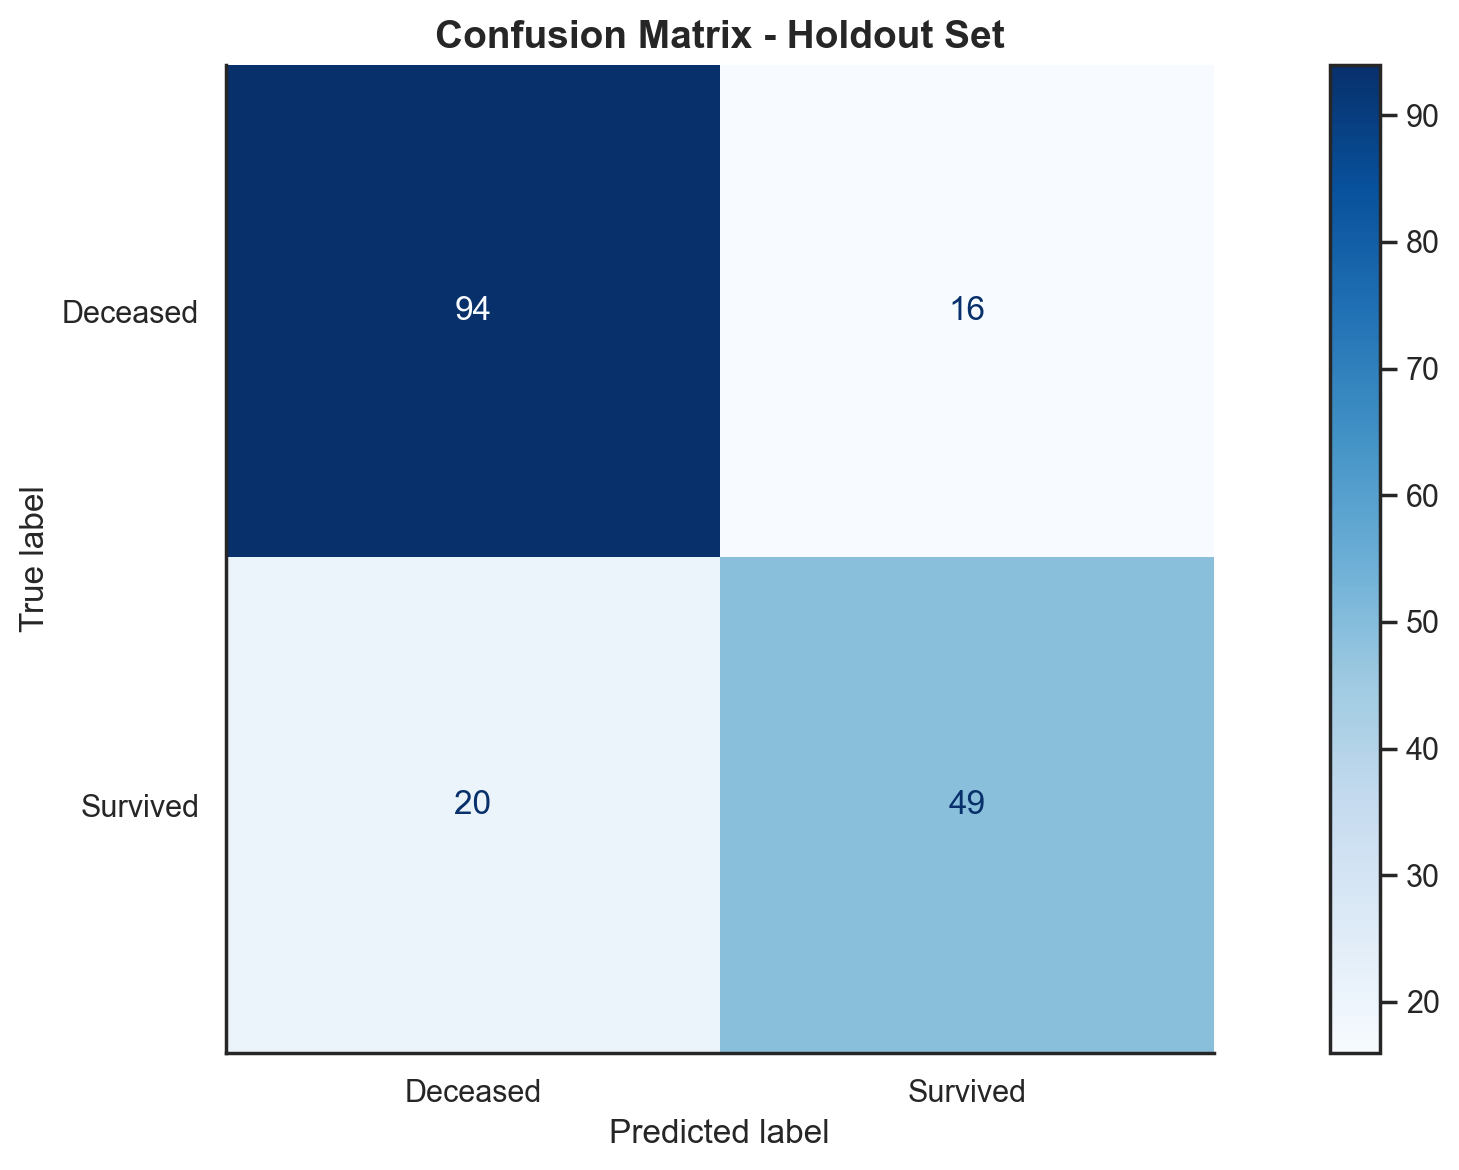

In [23]:
y_pred_holdout = best_optuna_model.predict(X_holdout).ravel().astype(int)

holdout_accuracy = accuracy_score(y_holdout, y_pred_holdout)

print(f"Holdout Accuracy: {holdout_accuracy:.4f}")
print(
    classification_report(
        y_holdout,
        y_pred_holdout,
        target_names=["Deceased", "Survived"],
        zero_division=0,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_holdout,
    y_pred_holdout,
    display_labels=["Deceased", "Survived"],
    cmap="Blues",
    values_format="d",
)

plt.title("Confusion Matrix - Holdout Set")
plt.tight_layout()
plt.show()

The optimized CatBoost model achieved a holdout accuracy of **0.7989** on the isolated 20% validation split. This result indicates that the model correctly classified approximately 80% of the holdout observations under the current preprocessing, feature engineering, and hyperparameter configuration.

The classification report shows stronger performance for the `Deceased` class than for the `Survived` class. For non-survivors, the model obtained precision of **0.82**, recall of **0.85**, and F1-score of **0.84**. For survivors, the model obtained precision of **0.75**, recall of **0.71**, and F1-score of **0.73**. This difference suggests that the model is more reliable at identifying passengers who did not survive than passengers who survived.

The confusion matrix confirms this pattern. Among the 110 passengers who did not survive, **94** were correctly classified and **16** were incorrectly predicted as survivors. Among the 69 passengers who survived, **49** were correctly classified and **20** were incorrectly predicted as non-survivors. Therefore, the main source of error in this holdout split is the misclassification of actual survivors as non-survivors.

The macro-average F1-score of **0.79** and weighted-average F1-score of **0.80** indicate that the model maintains reasonable overall performance, but class-level differences remain relevant. Since the survival class has lower recall, accuracy alone is not sufficient to fully describe model behavior.

These holdout metrics should be interpreted as local validation estimates for one stratified split and one random seed. They do not represent Kaggle leaderboard performance directly.


### Final Model Training (Full Dataset)

After holdout evaluation, the model is retrained using the full processed training dataset in order to maximize the labeled information available for final Kaggle predictions.

Final submission training is different from validation: preprocessing statistics are intentionally learned from all available training features, excluding `Survived`, and then applied to `test_df`. The reported holdout and cross-validation metrics are computed before this final refit and are not affected by the Kaggle test data.


In [24]:
final_model = CatBoostClassifier(
    **study.best_params,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_state=RANDOM_STATE,
    verbose=0,
)

final_model.fit(
    X_train,
    y_train,
    cat_features=catboost_cat_features
)

CatBoostClassifier(bagging_temperature=0.4971735467658833, depth=5, eval_metric='Accuracy', iterations=1037, l2_leaf_reg=5, learning_rate=0.03665819462253379, loss_function='Logloss', random_state=42, random_strength=1.3792021089374082, verbose=0)

## 7. Model Explainability

This section inspects the fitted CatBoost model using native feature importance and SHAP values. These analyses are diagnostic and should be read as explanations of the fitted model behavior, not as evidence that a feature independently improves validation performance.

### Native Feature Importance Analysis

We extract two CatBoost importance views:
1. **PredictionValuesChange:** measures how much model predictions change because of splits involving each feature.
2. **LossFunctionChange:** estimates the change in the loss function associated with each feature using a CatBoost `Pool`.


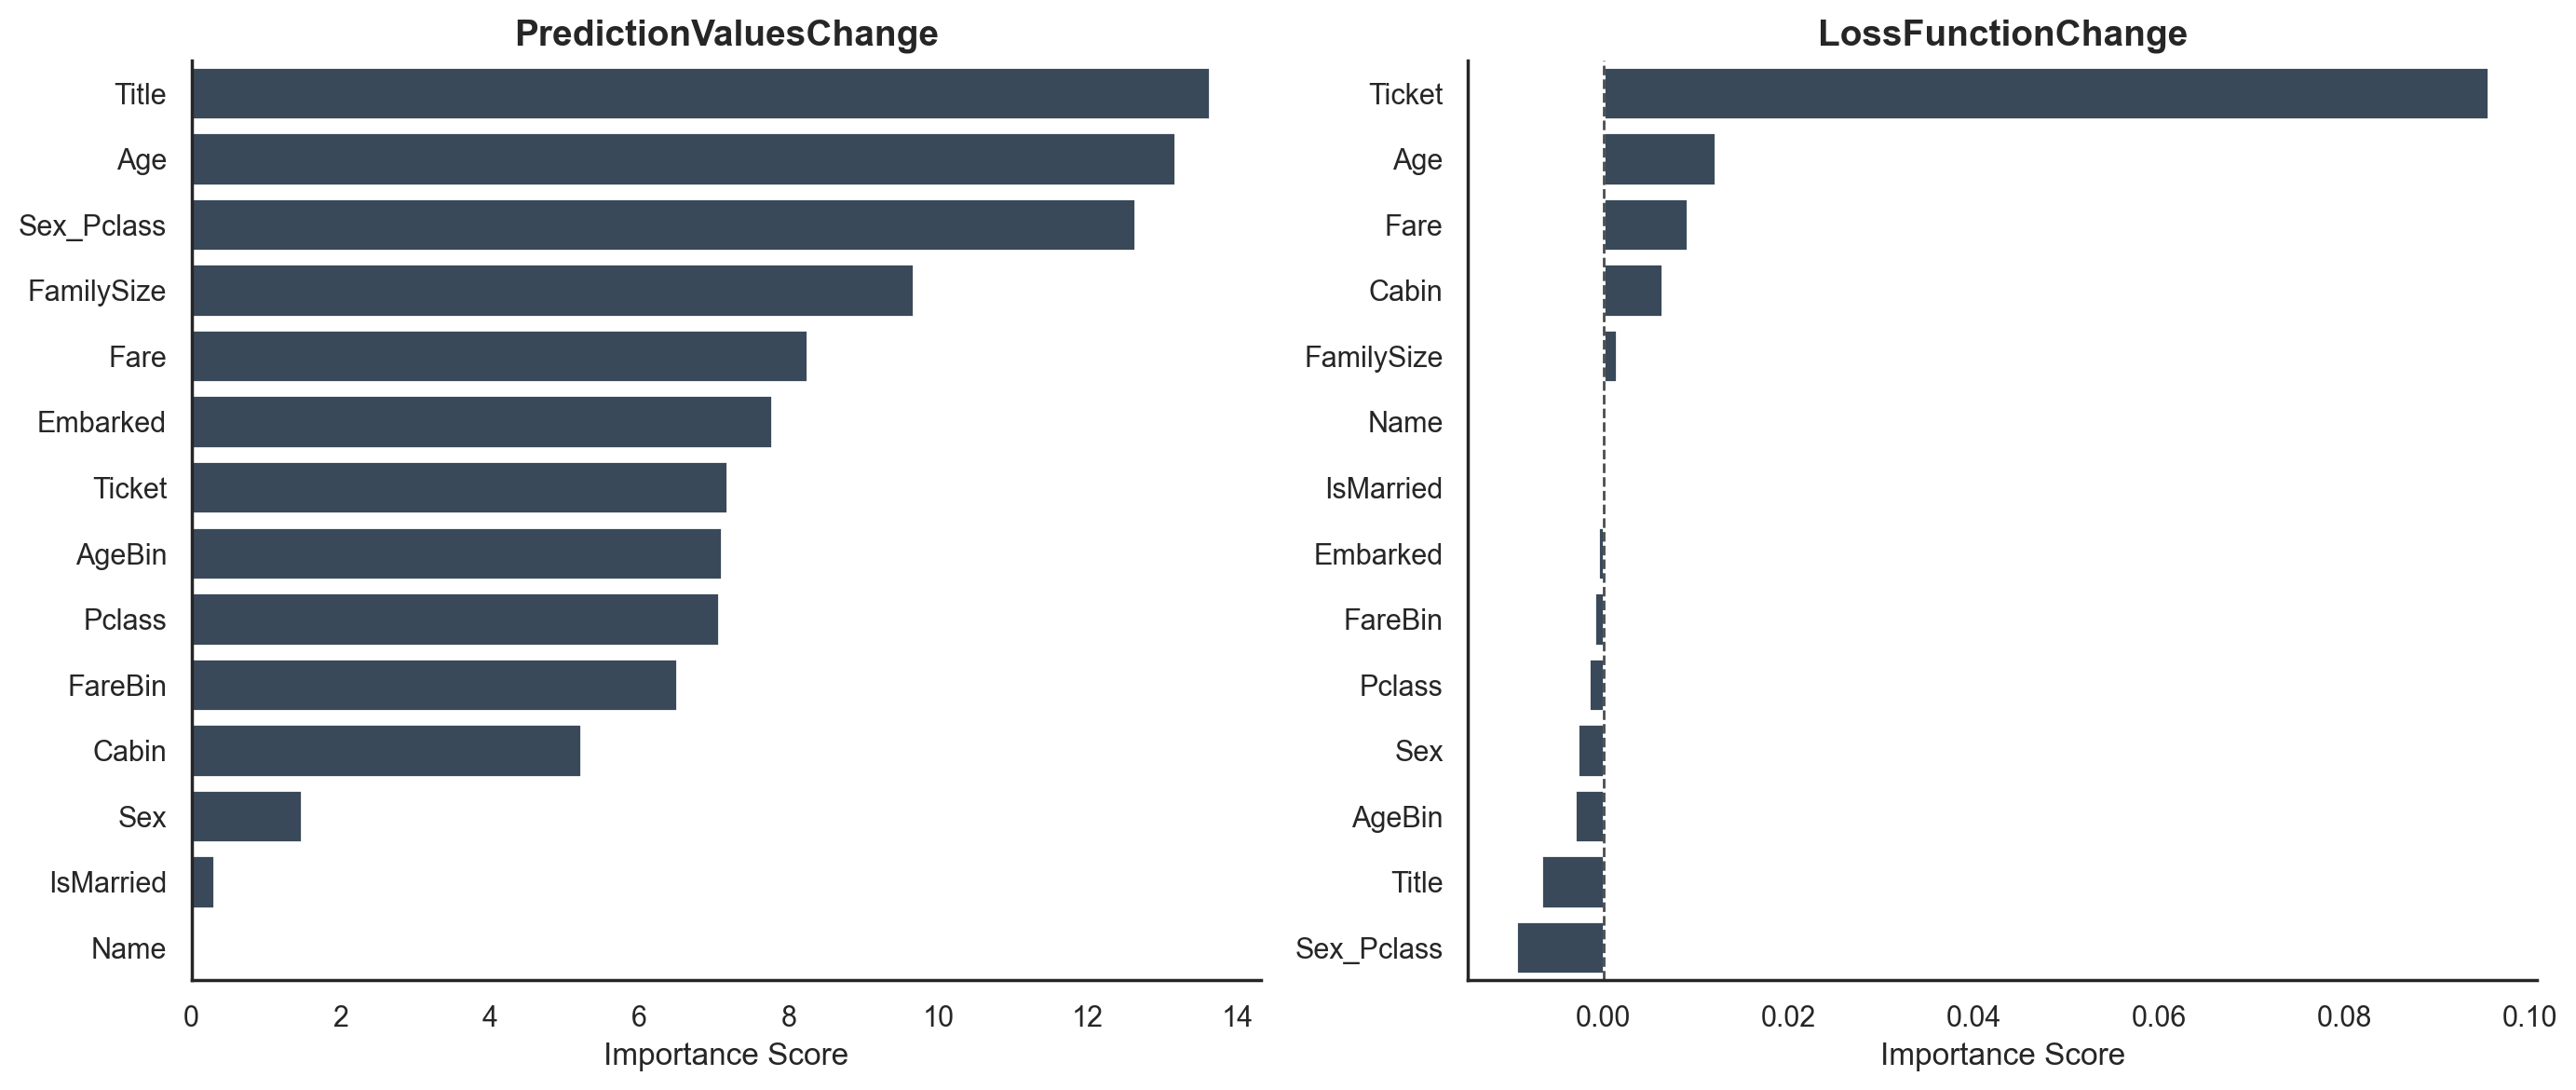

In [25]:
train_pool = Pool(
    X_train,
    label=y_train,
    cat_features=catboost_cat_features
)

imp_pvc = final_model.get_feature_importance(type="PredictionValuesChange")
df_pvc = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": imp_pvc
}).sort_values(by="Importance", ascending=False)

imp_lfc = final_model.get_feature_importance(
    data=train_pool,
    type="LossFunctionChange"
)
df_lfc = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": imp_lfc
}).sort_values(by="Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=df_pvc,
    ax=axes[0]
)
axes[0].set_title("PredictionValuesChange")
axes[0].set_xlabel("Importance Score")
axes[0].set_ylabel("")

sns.barplot(
    x="Importance",
    y="Feature",
    data=df_lfc,
    ax=axes[1]
)
axes[1].set_title("LossFunctionChange")
axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("")
axes[1].axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

The native CatBoost feature-importance diagnostics indicate that the fitted model relies on different groups of predictors depending on the importance criterion used. These rankings should be interpreted as model-behavior diagnostics computed on the final fitted estimator, not as causal evidence or as a formal feature ablation result.

In the `PredictionValuesChange` view, `Title`, `Age`, `Sex_Pclass`, `FamilySize`, `Fare`, `Embarked`, `Ticket`, and `AgeBin` appear among the most influential predictors. This suggests that the model frequently uses demographic, socioeconomic, family-structure, and grouped age/fare signals in splits that materially change predicted probabilities. The high position of `Title` and `Sex_Pclass` is consistent with the exploratory analysis, where sex, ticket class, and social role showed strong descriptive associations with survival.

The `LossFunctionChange` view provides a different perspective. In this diagnostic, `Ticket` is the dominant feature, followed by smaller positive contributions from `Age`, `Fare`, `Cabin`, and `FamilySize`. This indicates that, when evaluated against the training objective on the provided CatBoost `Pool`, `Ticket` contributes the largest estimated reduction in loss. However, this result should be interpreted cautiously because `Ticket` is a high-cardinality categorical variable. It may capture meaningful group-level structure, such as shared tickets, family groups, or travel parties, but it may also encode dataset-specific patterns that are less stable outside the training distribution.

The divergence between `PredictionValuesChange` and `LossFunctionChange` is expected. `PredictionValuesChange` measures how much feature-based splits alter model predictions, while `LossFunctionChange` estimates the marginal effect of each feature on the objective function. A feature can strongly affect prediction paths while adding limited incremental loss reduction if its information overlaps with other predictors. This appears to be the case for variables such as `Title` and `Sex_Pclass`, which rank highly under `PredictionValuesChange` but show limited or negative contribution under `LossFunctionChange`.

The presence of near-zero or negative values in `LossFunctionChange` should not be interpreted as definitive evidence that those features are useless. In tree-based models, correlated and derived predictors can share predictive signal. When several features encode similar information, such as `Sex`, `Title`, `IsMarried`, `Pclass`, and `Sex_Pclass`, the estimated contribution of one variable may decrease because the model can recover part of the same signal from another variable.

Overall, the importance diagnostics suggest that the final CatBoost model combines passenger identity/grouping information (`Ticket`, `Name`), demographic and social-role information (`Sex`, `Title`, `IsMarried`), socioeconomic information (`Pclass`, `Fare`, `Cabin`), and engineered family or interaction features (`FamilySize`, `Sex_Pclass`, `AgeBin`, `FareBin`). These results support the plausibility of the feature-engineering strategy, but they do not prove that each engineered feature independently improves generalization. A formal ablation study or repeated cross-validation experiment would be required to quantify the incremental contribution of each feature group.

### SHAP Values (Shapley Additive Explanations)

To complement the native CatBoost feature-importance diagnostics, SHAP values are computed for the final fitted model. SHAP decomposes each prediction into feature-level contributions, allowing both local inspection of individual predictions and aggregate inspection of model behavior. In this notebook, SHAP values are computed on the final training feature matrix (`X_train`). Therefore, the analysis should be interpreted as an in-sample explanation of the fitted model, not as an out-of-sample validation result.

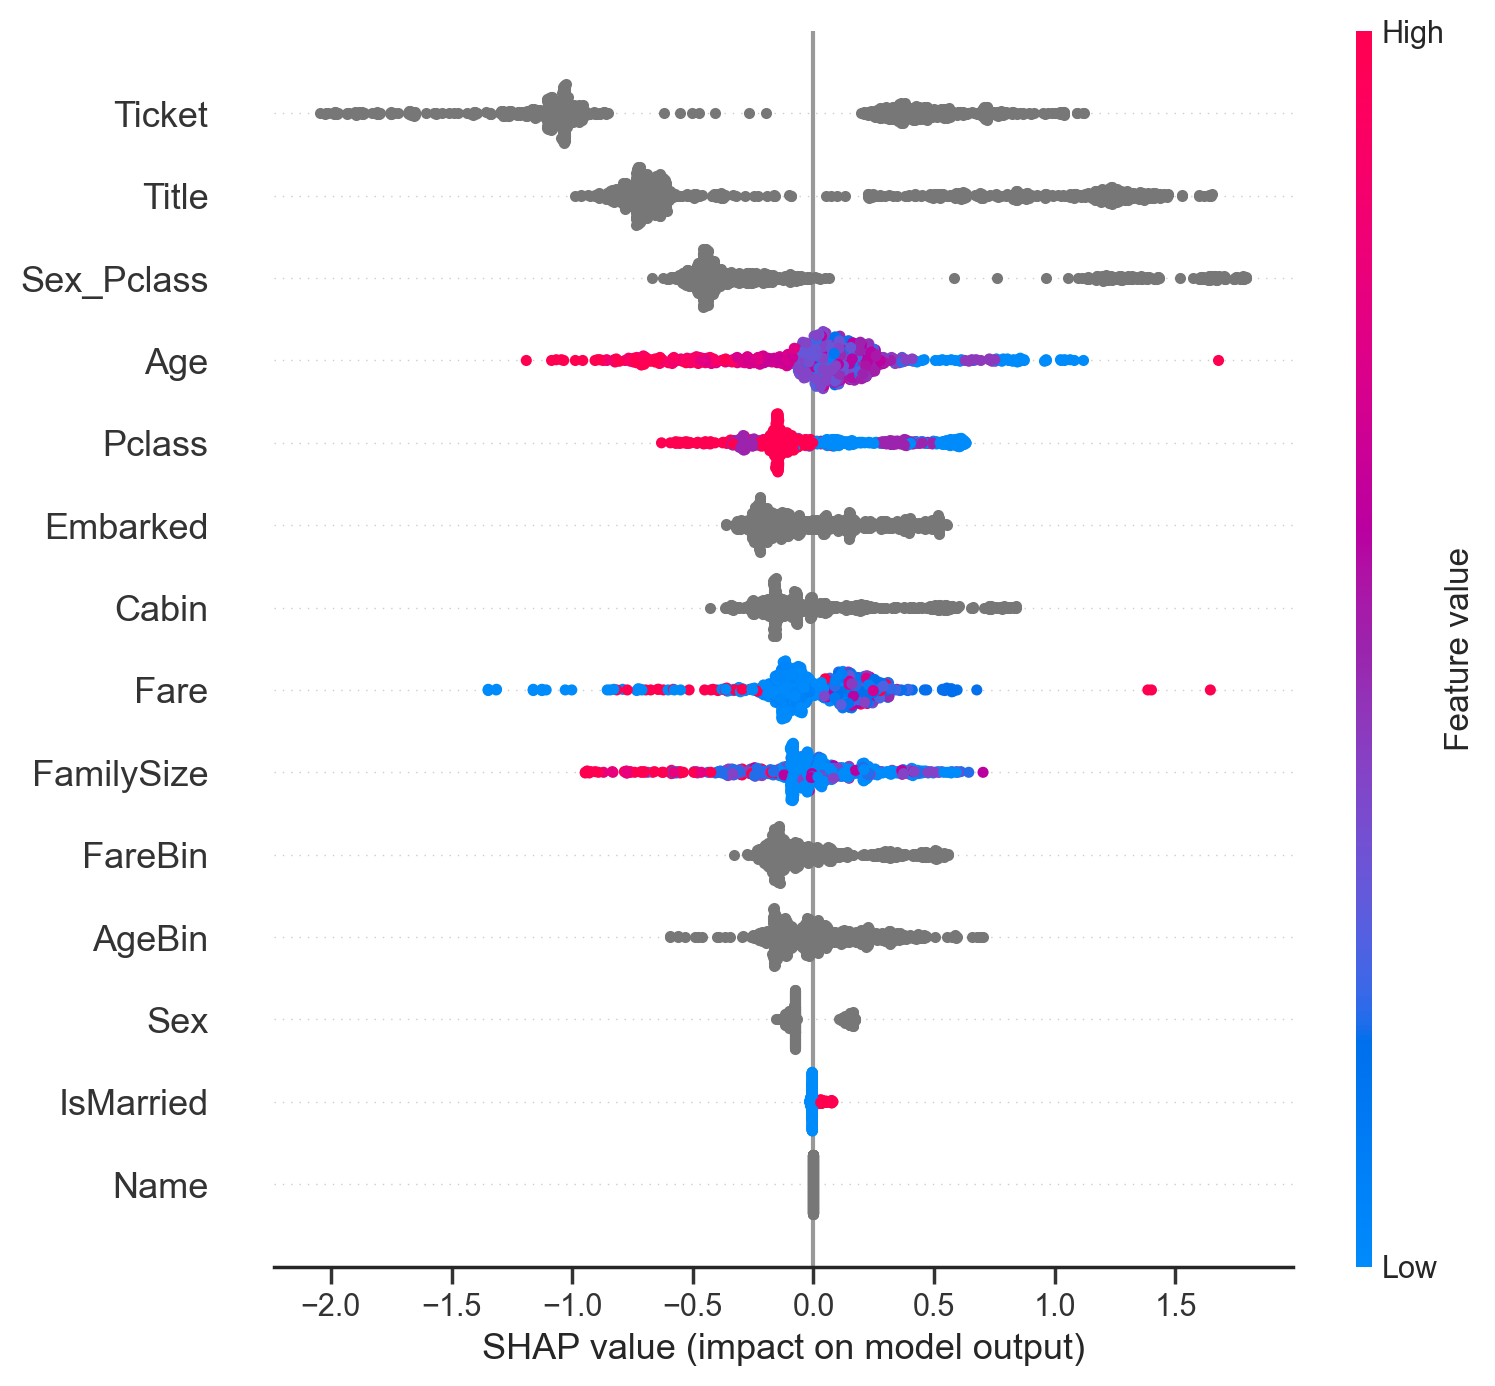

In [26]:
def adjust_binary_shap(shap_values: np.ndarray | list) -> np.ndarray:
    """
    Normalize SHAP outputs for binary classification models.
    Returns the SHAP values associated with the positive class.
    """
    if isinstance(shap_values, list):
        return shap_values[1]
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        return shap_values[:, :, 1]
    return shap_values


X_shap = X_train.copy()

explainer = shap.TreeExplainer(final_model)
shap_values = adjust_binary_shap(explainer.shap_values(X_shap))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="dot"
)

For binary classification, positive SHAP values increase the model output toward the positive class (`Survived = 1`), while negative SHAP values decrease the model output toward the non-survival class (`Survived = 0`). These values are model-output contributions rather than direct changes in accuracy or causal effects.

The SHAP summary plot ranks features by mean absolute SHAP value. In the reproduced plot, `Ticket` appears as the strongest contributor, followed by `Title`, `Sex_Pclass`, `Age`, `Pclass`, `Embarked`, `Cabin`, `Fare`, `FamilySize`, and `FareBin`. This indicates that the fitted CatBoost model relies heavily on a combination of ticket-level grouping information, title-based social-role information, demographic structure, socioeconomic proxies, and engineered interaction features.

The strong contribution of `Ticket` requires cautious interpretation. As a high-cardinality categorical variable, `Ticket` may capture meaningful structure, such as shared tickets, family groups, travel parties, or fare/class-related patterns. However, it may also encode dataset-specific information that is less stable outside the training distribution. Its high SHAP importance should therefore be interpreted as evidence that the fitted model uses this feature, not as proof that `Ticket` independently improves generalization.

For numerical predictors, the color gradient provides additional directional information. In the plot, `Age`, `Fare`, `Pclass`, and `FamilySize` show variation in both magnitude and direction of SHAP effects, suggesting non-linear behavior captured by the model. For categorical and text-like predictors, many points are shown in gray, so the plot is more informative about effect magnitude and dispersion than about ordered high-versus-low feature values.

Overall, the SHAP analysis supports the interpretation that the final model combines raw categorical signals (`Ticket`, `Cabin`, `Name`), demographic and social-role signals (`Title`, `Sex_Pclass`, `Age`), socioeconomic information (`Pclass`, `Fare`), and engineered grouped features (`FamilySize`, `AgeBin`, `FareBin`). These explanations describe the fitted model's internal behavior and should not be interpreted as causal evidence or as a substitute for feature ablation, repeated validation, or leaderboard evaluation.


### Out-of-Fold (OOF) Diagnostic

To complement the holdout evaluation, we compute Out-of-Fold (OOF) predictions across the raw labeled training set. In this procedure, each observation is predicted by a model trained without access to that observation within the OOF loop.

The preprocessing path is also rebuilt inside each OOF fold, so imputation statistics are learned only from each fold's training rows. This OOF result is still a post-selection diagnostic because the hyperparameters have already been selected by Optuna.


              precision    recall  f1-score   support

Perished (0)       0.85      0.92      0.88       549
Survived (1)       0.85      0.73      0.79       342

    accuracy                           0.85       891
   macro avg       0.85      0.83      0.83       891
weighted avg       0.85      0.85      0.84       891



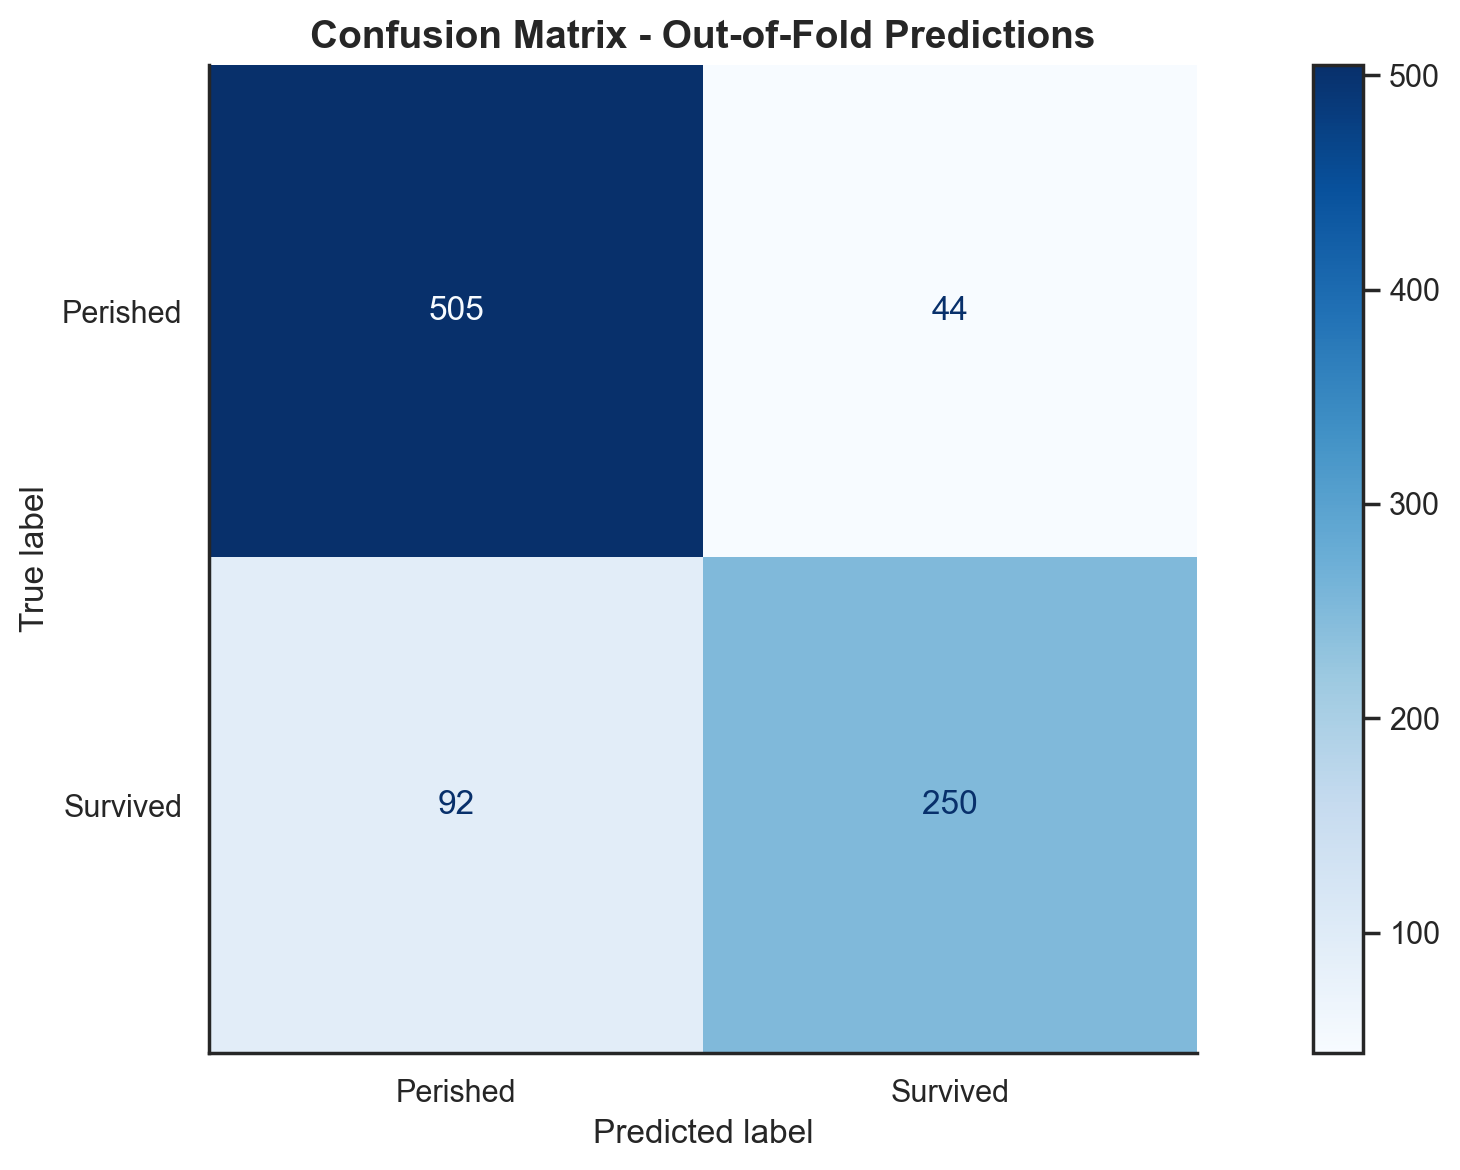

In [27]:
X_oof_raw = train_df.drop(columns=["Survived"])
y_oof = train_df["Survived"].astype(int)
oof_pred = np.zeros(len(y_oof), dtype=int)

# OOF diagnostic: preprocessing is also refit inside each fold.
for train_idx, valid_idx in cv_strategy.split(X_oof_raw, y_oof):
    X_train_fold_raw = X_oof_raw.iloc[train_idx]
    X_valid_fold_raw = X_oof_raw.iloc[valid_idx]
    y_train_fold = y_oof.iloc[train_idx]

    X_train_fold, X_valid_fold, fold_cat_features, _ = prepare_fold_matrices(
        X_train_fold_raw,
        X_valid_fold_raw
    )

    model = CatBoostClassifier(
        **study.best_params,
        loss_function="Logloss",
        eval_metric="Accuracy",
        random_state=RANDOM_STATE,
        verbose=0
    )

    model.fit(
        X_train_fold,
        y_train_fold,
        cat_features=fold_cat_features
    )

    oof_pred[valid_idx] = model.predict(X_valid_fold).ravel().astype(int)

print(classification_report(
    y_oof,
    oof_pred,
    target_names=["Perished (0)", "Survived (1)"]
))

ConfusionMatrixDisplay.from_predictions(
    y_oof,
    oof_pred,
    display_labels=["Perished", "Survived"],
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix - Out-of-Fold Predictions")
plt.tight_layout()
plt.show()


The classification report indicates balanced precision across both classes, with precision of **0.85** for `Perished (0)` and **0.85** for `Survived (1)`. However, recall differs substantially by class. The model achieves high recall for the non-survival class (**0.92**) but lower recall for the survival class (**0.73**). This indicates that the model is better at identifying passengers who did not survive than at recovering all actual survivors.

The confusion matrix confirms this asymmetry. Among the 549 passengers who did not survive, **505** were correctly classified and **44** were incorrectly predicted as survivors. Among the 342 passengers who survived, **250** were correctly classified and **92** were incorrectly predicted as non-survivors. Therefore, the main residual error pattern remains the misclassification of actual survivors as non-survivors.

Compared with the holdout result, the OOF diagnostic is materially stronger, with accuracy increasing from **0.7989** on the holdout split to approximately **0.8474** in the OOF evaluation. This gap should not be interpreted automatically as a true performance gain. The holdout result is based on one isolated stratified split, while the OOF result aggregates predictions across five folds and uses a post-selected hyperparameter configuration. The discrepancy suggests that local validation performance is sensitive to the evaluation protocol and should be interpreted together with the Kaggle public leaderboard score.

Overall, the OOF diagnostic suggests that the model captures a strong signal for the Titanic survival task, especially for the non-survival class.

## 8. Kaggle Submission Generation

The final fitted CatBoost model is used to generate predictions for the processed Kaggle test feature matrix (`X_test`). The submission file preserves the original `PassengerId` values from `test_df` and writes the predicted `Survived` labels to `../outputs/submission.csv`, following the expected Kaggle submission format.


In [28]:
# Predict labels for the Kaggle test set using the final fitted model.
test_predictions = final_model.predict(X_test).ravel().astype(int)

# Ensure the output directory exists.
output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Build the Kaggle submission dataframe.
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions
})

# Save the submission file in Kaggle format.
submission_path = output_dir / "submission.csv"
submission.to_csv(submission_path, index=False)

## 9. Experiment Limitations

The local validation workflow was designed to reduce preprocessing leakage. The holdout split, Optuna cross-validation objective, and OOF diagnostic rebuild the preprocessing pipeline from raw rows, ensuring that validation rows do not influence the imputation statistics used for `Embarked`, `Fare`, or `Age`.

However, the OOF result should still be interpreted as a post-selection diagnostic rather than as an unbiased estimate of generalization performance, since the hyperparameters were already selected by Optuna before the OOF loop was executed.

This notebook evaluates only CatBoost. It does not compare additional model families, such as logistic regression, random forest, gradient boosting variants, or calibrated ensemble methods. It also does not perform a controlled feature ablation study. As a result, the contribution of each engineered feature cannot be isolated from the combined modeling pipeline.

The native CatBoost feature-importance and SHAP analyses describe how the fitted model uses the available predictors, but they should not be interpreted as causal evidence or as proof that any individual feature independently improves generalization. This caution is especially relevant for high-cardinality predictors such as `Ticket`, which may capture useful grouping structure but may also encode dataset-specific patterns.

Finally, the reported Kaggle score refers to the public leaderboard evaluation and should not be treated as a definitive estimate of private leaderboard performance.


## 10. Conclusion and Next Steps

The current best submission from this notebook has a public Kaggle score of **0.79904**. In the experiment log, the best observed configuration corresponds to the CatBoost model using native categorical handling, with `Pclass`, `IsMarried`, and `FamilySize` treated as categorical predictors in addition to the text-like categorical columns.

The results suggest that this broader categorical-feature definition improved the public leaderboard score relative to the previous tested configurations. However, because the notebook does not include a controlled ablation study, this should be interpreted as an empirical observation from the experiment log rather than as isolated proof of incremental feature value.

Several subsequent feature-engineering or feature-removal attempts did not improve the public Kaggle score, including `IsAlone`, `TicketPrefix`, `TicketGroupSize`, `Deck`, `RoleGroup`, removing `Name`, removing `Cabin`, and removing `AgeBin`/`FareBin` together. These results indicate that additional engineered features do not necessarily improve performance and may introduce noise, redundancy, or unstable dataset-specific patterns.
